In [60]:
import pickle

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import obspy
from seismicif.datamod.trigger_utils import trace_trigger_detections

from seismicif.datamod.loading_utils import (
    preproc_flow_annotations,
    find_paths,
    find_date_in_strings,
    read_segment,
    sliding_windows_from_trace,
    sliding_windows_from_stream,
)
from seismicif.metrics import iou
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform
from dynamicTreeCut import cutreeHybrid
from scipy.spatial.distance import pdist
from datetime import timedelta
from seismicif.datamod.preproc_utils import preproc_stream
from seismicif.datamod.loading_utils import limit_segment_length
import joblib
from tqdm import tqdm


def print_cluster_info(clusters, labels):
    for i in np.unique(clusters):
        cluster_labs = labels[clusters == i]
        cluster_labs_non_none = [x for x in cluster_labs if x is not None]

        if cluster_labs_non_none:
            print(f"Cluster {i}:")
            print(cluster_labs_non_none)
            print(np.sum(clusters == i))


def cluster_info(cluster):
    size = len(cluster)

    mapping = {"CAL": "MM", "ID": "MM", "TEQ": "EQ", "REQ": "EQ"}

    cluster["label"] = cluster["label"].replace(mapping)

    return cluster["label"].value_counts(dropna=False) / size

In [61]:
station = "KARAT"
network = "DK"
karat_paths = paths = find_paths("DK", "KARAT", "HHZ.D", start=2022, stop=2023)
control_paths = find_paths("DK", "KARAT_CONT", "HHZ.D", start=2022, stop=2023)

catalog = pd.read_csv("../catalogs/DK/KARAT.csv")
catalog = preproc_flow_annotations(catalog)
segments = pd.read_csv(f"../output/{network}/if/segments/{station}.csv", index_col=0)

if_mod = joblib.load(f"../output/{network}/if/models/{station}.joblib")

dtw_path = f"../output/backup/KARAT_200.pkl"

with open(f"{dtw_path}", "rb") as f:
    results = pickle.load(f)

X = np.zeros((len(results), len(results[0])))
for i in range(len(results)):
    X[i] = np.array([np.median(results[i][k][0]) for k in range(len(results[i]))])

In [80]:
catalog

,start,stop,label,remarks
0,2022-05-30T13:35:29.900000Z,2022-05-30T13:39:39.900000Z,N,instrument
1,2022-05-31T07:01:09.385000Z,2022-05-31T07:06:09.385000Z,N,instrument
2,2022-06-03T10:01:34.625000Z,2022-06-03T10:05:44.625000Z,N,instrument
3,2022-06-11T13:51:33.165000Z,2022-06-11T23:59:53.165000Z,N,instrument
4,2022-06-12T00:00:00.000000Z,2022-06-13T11:07:30.000000Z,N,instrument
...,...,...,...,...
212,2023-10-14T05:40:00.000000Z,2023-10-14T05:50:50.000000Z,N,extremely weak signal if any
213,2023-10-14T05:52:30.000000Z,2023-10-14T06:03:20.000000Z,CAL,very weak signal
214,2023-10-16T09:47:30.000000Z,2023-10-16T15:35:50.000000Z,TEQ,NaN
215,2023-10-16T11:44:10.000000Z,2023-10-16T11:50:00.000000Z,TEQ,"M 6.4 - 78 km NNW of Adak, Alaska. 174km depth"


In [87]:
labs = np.array([""] * len(segments), dtype=object)
remark = np.array([""] * len(segments), dtype=object)

start_catalog = []
for i in range(len(segments)):
    I, _, _ = iou(catalog, segments.iloc[[i]].reset_index(drop=True))
    try:
        labs[i] = catalog["label"][np.where(np.append(I[0], np.diff(I)) > 0)[0]].values[
            0
        ]
        start_catalog.append(catalog.iloc[np.where(np.append(I[0], np.diff(I)) > 0)[0]])
        remark[i] = catalog["remarks"][
            np.where(np.append(I[0], np.diff(I)) > 0)[0]
        ].values[0]
    except IndexError:
        labs[i] = ""
        remark[i] = ""

# labs = np.array(labs)

start_catalog = pd.concat(start_catalog).reset_index(drop=True)
segments["remarks"] = remark

In [88]:
segments

,start,stop,most_anomalous_start,scores,control_scores,cluster,label,remarks
0,2022-05-30T13:35:29.900000Z,2022-05-30T13:39:39.900000Z,2022-05-30T13:35:29.900000Z,0.747250,0.366479,13,N,instrument
1,2022-06-03T10:01:34.625000Z,2022-06-03T10:05:44.625000Z,2022-06-03T10:04:04.625000Z,0.742787,0.364854,8,N,instrument
2,2022-05-31T07:01:09.385000Z,2022-05-31T07:06:09.385000Z,2022-05-31T07:02:49.385000Z,0.742488,0.568778,13,N,instrument
3,2022-06-14T00:00:00.000000Z,2022-06-14T14:47:30.000000Z,2022-06-14T10:18:20.000000Z,0.742142,0.536593,13,N,instrument
4,2022-06-12T00:00:00.000000Z,2022-06-13T11:07:30.000000Z,2022-06-13T09:45:50.000000Z,0.739093,0.564561,13,N,instrument
...,...,...,...,...,...,...,...,...
600,2022-12-10T03:22:00.390000Z,2022-12-10T03:39:30.390000Z,2022-12-10T03:22:00.390000Z,0.600086,0.496248,7,,
601,2022-11-13T01:53:49.420000Z,2022-11-13T01:56:19.420000Z,2022-11-13T01:53:49.420000Z,0.600083,0.494014,1,,
602,2022-10-14T21:34:05.350000Z,2022-10-14T21:59:05.350000Z,2022-10-14T21:34:05.350000Z,0.600077,0.494979,7,,
603,2022-10-14T05:53:15.350000Z,2022-10-14T06:03:15.350000Z,2022-10-14T05:53:15.350000Z,0.600064,0.446380,2,,


In [53]:
# Xn =np.load("../output/backup/karat_dtw_distances.npy")

In [63]:
Xa = X.copy()
lens = []

for i in range(len(segments)):
    start = obspy.UTCDateTime(segments["start"][i])
    stop = obspy.UTCDateTime(segments["stop"][i])
    lens.append(min(stop - start, 1800))

lens = np.array(lens)
lens = lens.reshape(-1, 1)
Xa = np.hstack([Xa, lens])
Xa = np.hstack([Xa, segments[["scores", "control_scores"]].values])

a = np.nanmin(Xa, axis=0)
b = np.nanmax(Xa, axis=0)
Xa = (Xa - a) / (b - a)

# a = np.nanmean(Xa,axis=0)
# b = np.nanstd(Xa,axis=0)
# Xa = (Xa - a) / b

In [64]:
Z = linkage(Xa, method="ward")
D = squareform(pdist(Xa, metric="euclidean"))
clusters = cutreeHybrid(Z, D, minClusterSize=10, deepSplit=3)
clusters = clusters["labels"]
segments["cluster"] = clusters
segments["label"] = labs
segments.to_csv(f"../output/{network}/if/segments/{station}.csv")

..cutHeight not given, setting it to 20.76284980709905  ===>  99% of the (truncated) height range in dendro.
..done.


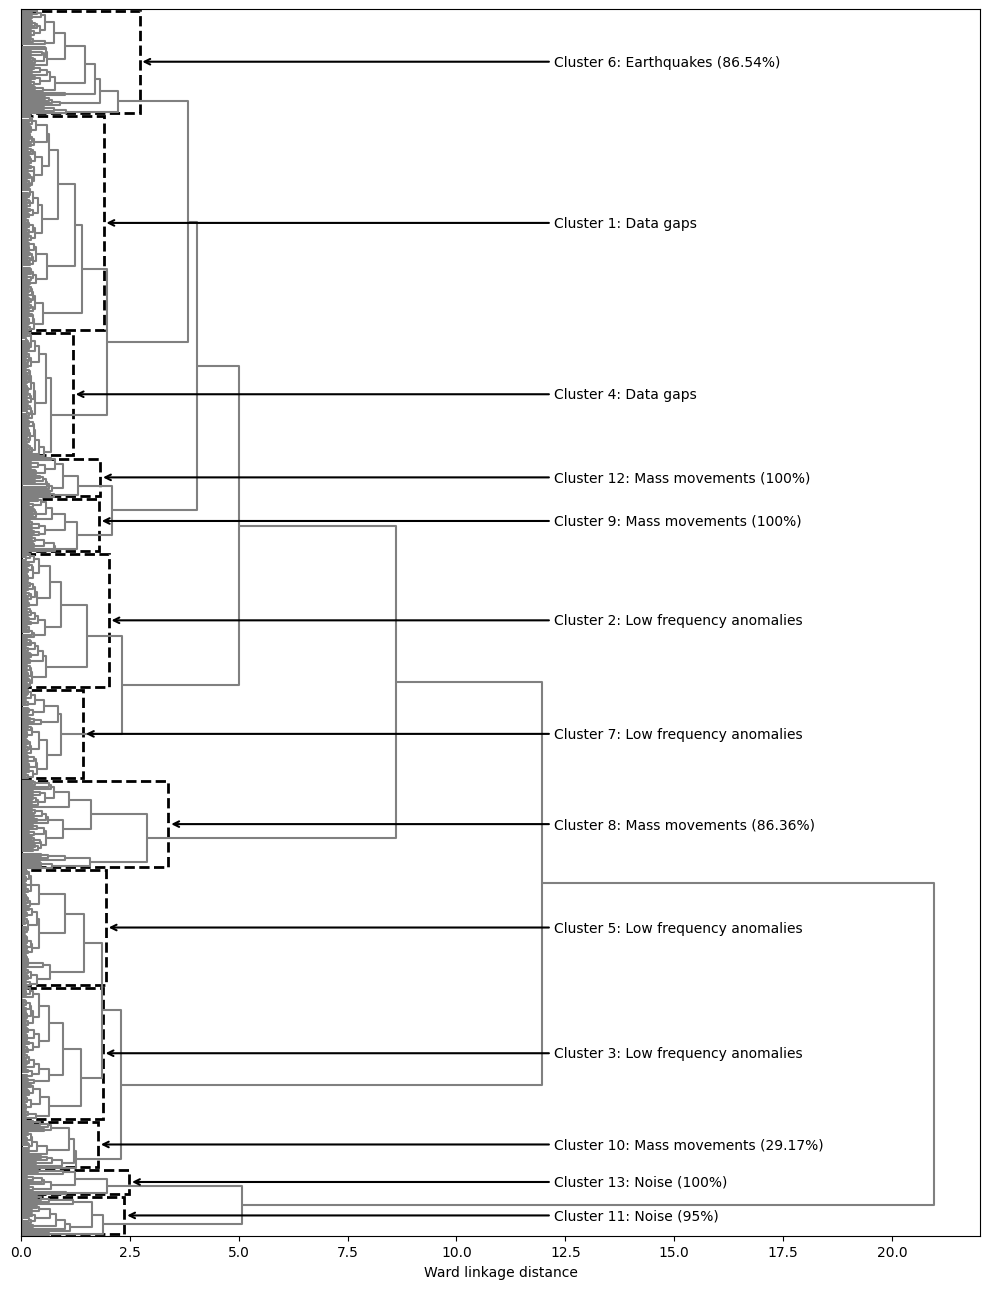

In [198]:
plt.figure(figsize=(10, 13))

ddata = dendrogram(
    Z, link_color_func=lambda k: "grey", orientation="right", no_labels=True
)

leaf_order = ddata["leaves"]
clusters_ordered = clusters[leaf_order]

ax = plt.gca()
x_positions = np.arange(len(leaf_order)) * 10 + 5

n = len(clusters)
node_members = {i: {i} for i in range(n)}
node_height = {i: 0 for i in range(n)}

for i, (c1, c2, dist, _) in enumerate(Z):
    c1, c2 = int(c1), int(c2)
    new_id = n + i

    members = node_members[c1] | node_members[c2]
    node_members[new_id] = members
    node_height[new_id] = dist

# --- compute height per cluster ---
cluster_heights = {}

for node_id, members in node_members.items():
    member_clusters = set(clusters[list(members)])

    if len(member_clusters) == 1:
        cid = next(iter(member_clusters))
        cluster_heights[cid] = max(cluster_heights.get(cid, 0), node_height[node_id])


y_positions = np.arange(len(leaf_order)) * 10 + 5

for cid in np.unique(clusters):
    idx = np.where(clusters_ordered == cid)[0]

    if len(idx) == 0:
        continue

    y0 = y_positions[idx.min()] - 5 + gap
    y1 = y_positions[idx.max()] + 5 - gap
    width = cluster_heights.get(cid, 0) + 0.5

    rect = plt.Rectangle(
        (0, y0),  # start at x=0 now
        width,  # width instead of height
        y1 - y0,
        fill=False,
        edgecolor="black",
        linewidth=2,
        linestyle="--",
    )
    ax.add_patch(rect)

    x_stop = 12.25

    if cid == 1:
        y_center = (y0 + y1) / 2
        x_start = width

        ax.annotate(
            "Cluster 1: Data gaps",  # text
            xy=(x_start, y_center),  # arrow start (on box)
            xytext=(x_stop, y_center),  # text position (to the right)
            va="center",
            arrowprops=dict(
                arrowstyle="->",
                linewidth=1.5,
            ),
        )

    if cid == 2:
        y_center = (y0 + y1) / 2
        x_start = width

        ax.annotate(
            "Cluster 2: Low frequency anomalies",  # text
            xy=(x_start, y_center),  # arrow start (on box)
            xytext=(x_stop, y_center),  # text position (to the right)
            va="center",
            arrowprops=dict(
                arrowstyle="->",
                linewidth=1.5,
            ),
        )

    if cid == 3:
        y_center = (y0 + y1) / 2
        x_start = width

        ax.annotate(
            "Cluster 3: Low frequency anomalies",  # text
            xy=(x_start, y_center),  # arrow start (on box)
            xytext=(x_stop, y_center),  # text position (to the right)
            va="center",
            arrowprops=dict(
                arrowstyle="->",
                linewidth=1.5,
            ),
        )

    if cid == 4:
        y_center = (y0 + y1) / 2
        x_start = width

        ax.annotate(
            "Cluster 4: Data gaps",  # text
            xy=(x_start, y_center),  # arrow start (on box)
            xytext=(x_stop, y_center),  # text position (to the right)
            va="center",
            arrowprops=dict(
                arrowstyle="->",
                linewidth=1.5,
            ),
        )

    if cid == 5:
        y_center = (y0 + y1) / 2
        x_start = width

        ax.annotate(
            "Cluster 5: Low frequency anomalies",  # text
            xy=(x_start, y_center),  # arrow start (on box)
            xytext=(x_stop, y_center),  # text position (to the right)
            va="center",
            arrowprops=dict(
                arrowstyle="->",
                linewidth=1.5,
            ),
        )

    if cid == 6:
        y_center = (y0 + y1) / 2
        x_start = width

        ax.annotate(
            "Cluster 6: Earthquakes (86.54%)",  # text
            xy=(x_start, y_center),  # arrow start (on box)
            xytext=(x_stop, y_center),  # text position (to the right)
            va="center",
            arrowprops=dict(
                arrowstyle="->",
                linewidth=1.5,
            ),
        )

    if cid == 7:
        y_center = (y0 + y1) / 2
        x_start = width

        ax.annotate(
            "Cluster 7: Low frequency anomalies",  # text
            xy=(x_start, y_center),  # arrow start (on box)
            xytext=(x_stop, y_center),  # text position (to the right)
            va="center",
            arrowprops=dict(
                arrowstyle="->",
                linewidth=1.5,
            ),
        )

    if cid == 8:
        y_center = (y0 + y1) / 2
        x_start = width

        ax.annotate(
            "Cluster 8: Mass movements (86.36%)",  # text
            xy=(x_start, y_center),  # arrow start (on box)
            xytext=(x_stop, y_center),  # text position (to the right)
            va="center",
            arrowprops=dict(
                arrowstyle="->",
                linewidth=1.5,
            ),
        )

    if cid == 9:
        y_center = (y0 + y1) / 2 + 20
        x_start = width

        ax.annotate(
            "Cluster 9: Mass movements (100%)",  # text
            xy=(x_start, y_center),  # arrow start (on box)
            xytext=(x_stop, y_center),  # text position (to the right)
            va="center",
            arrowprops=dict(
                arrowstyle="->",
                linewidth=1.5,
            ),
        )

    if cid == 10:
        y_center = (y0 + y1) / 2
        x_start = width

        ax.annotate(
            "Cluster 10: Mass movements (29.17%)",  # text
            xy=(x_start, y_center),  # arrow start (on box)
            xytext=(x_stop, y_center),  # text position (to the right)
            va="center",
            arrowprops=dict(
                arrowstyle="->",
                linewidth=1.5,
            ),
        )

    if cid == 11:
        y_center = (y0 + y1) / 2
        x_start = width

        ax.annotate(
            "Cluster 11: Noise (95%)",  # text
            xy=(x_start, y_center),  # arrow start (on box)
            xytext=(x_stop, y_center),  # text position (to the right)
            va="center",
            arrowprops=dict(
                arrowstyle="->",
                linewidth=1.5,
            ),
        )

    if cid == 12:
        y_center = (y0 + y1) / 2
        x_start = width

        ax.annotate(
            "Cluster 12: Mass movements (100%)",  # text
            xy=(x_start, y_center),  # arrow start (on box)
            xytext=(x_stop, y_center),  # text position (to the right)
            va="center",
            arrowprops=dict(
                arrowstyle="->",
                linewidth=1.5,
            ),
        )

    if cid == 13:
        y_center = (y0 + y1) / 2
        x_start = width

        ax.annotate(
            "Cluster 13: Noise (100%)",  # text
            xy=(x_start, y_center),  # arrow start (on box)
            xytext=(x_stop, y_center),  # text position (to the right)
            va="center",
            arrowprops=dict(
                arrowstyle="->",
                linewidth=1.5,
            ),
        )


plt.xlabel("Ward linkage distance")
plt.tight_layout()
plt.savefig("../plots/karat_dendrogram.pdf", dpi=300)
plt.show()

In [176]:
mask = np.array(segments["label"] == "CAL") | np.array(segments["label"] == "ID")

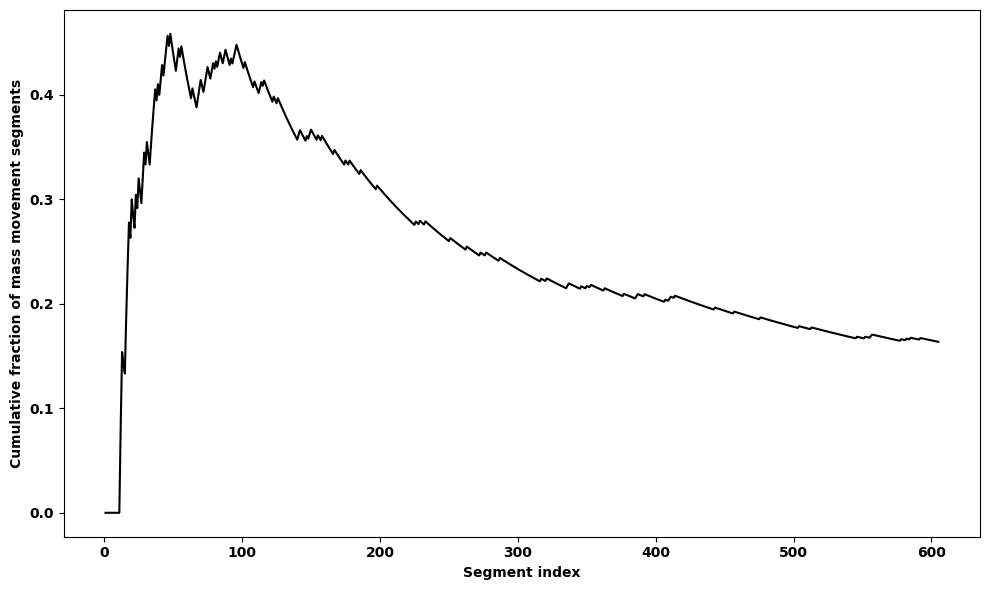

In [240]:
x = np.arange(1, len(mask) + 1)
y = np.cumsum(mask) / np.arange(1, len(mask) + 1)


plt.figure(figsize=(10, 6))
plt.plot(x, y, c="k")
plt.xlabel("Segment index", fontweight="bold")
plt.ylabel("Cumulative fraction of mass movement segments", fontweight="bold")

ax = plt.gca()

for label in ax.get_xticklabels() + ax.get_yticklabels() + ax.get_yticklabels():
    label.set_fontweight("bold")

plt.tight_layout()
plt.savefig("../plots/cum_frac.pdf", dpi=300)
plt.show()

In [241]:
np.argmax(y)

47

In [109]:
clusters.max()

13

In [196]:
info = {}
for cl in np.unique(clusters):
    cluster = segments[clusters == cl].copy()
    info[cl] = cluster_info(cluster)


df = pd.DataFrame(info).T
df.fillna(0, inplace=True)
df.columns = ["unknown"] + list(df.columns[1:])
df.index.name = "cluster"
df

,unknown,EQ,MM,N
cluster,,,,
1,0.934579,0.009346,0.000000,0.056075
2,0.701493,0.014925,0.029851,0.253731
3,0.969697,0.015152,0.000000,0.015152
4,1.000000,0.000000,0.000000,0.000000
5,0.982759,0.000000,0.017241,0.000000
6,0.000000,0.865385,0.057692,0.076923
7,0.955556,0.000000,0.000000,0.044444
8,0.000000,0.000000,0.863636,0.136364
9,0.000000,0.000000,1.000000,0.000000


In [217]:
cluster = segments[clusters == 8]
cluster.shape[0]

44

In [218]:
cluster

,start,stop,most_anomalous_start,scores,control_scores,cluster,label,remarks
1,2022-06-03T10:01:34.625000Z,2022-06-03T10:05:44.625000Z,2022-06-03T10:04:04.625000Z,0.742787,0.364854,8,N,instrument
15,2023-08-25T12:39:10.000000Z,2023-08-25T12:47:30.000000Z,2023-08-25T12:41:40.000000Z,0.720424,0.462266,8,CAL,verified by Satellite images on 22-08 and 28-08
18,2022-08-16T12:32:30.000000Z,2022-08-16T12:41:40.000000Z,2022-08-16T12:35:00.000000Z,0.716862,0.410301,8,N,anthropogenic
25,2022-08-15T22:40:54.845000Z,2022-08-15T22:55:54.845000Z,2022-08-15T22:43:24.845000Z,0.702885,0.422594,8,N,instrument
40,2022-11-17T12:00:18.390000Z,2022-11-17T12:03:38.390000Z,2022-11-17T12:01:08.390000Z,0.685305,0.496414,8,CAL,NaN
41,2023-08-15T03:56:40.000000Z,2023-08-15T04:00:00.000000Z,2023-08-15T03:57:30.000000Z,0.684699,0.378697,8,CAL,NaN
43,2023-06-10T11:09:02.320000Z,2023-06-10T11:12:22.320000Z,2023-06-10T11:09:02.320000Z,0.682479,0.416961,8,CAL,Seiche signal TEQ an hour before
44,2023-09-18T13:38:25.410000Z,2023-09-18T13:43:25.410000Z,2023-09-18T13:40:05.410000Z,0.678498,0.458657,8,CAL,NaN
52,2022-09-21T22:12:12.395000Z,2022-09-21T22:15:32.395000Z,2022-09-21T22:12:12.395000Z,0.670336,0.455837,8,CAL,uncertain
67,2023-06-12T09:46:32.320000Z,2023-06-12T09:50:42.320000Z,2023-06-12T09:46:32.320000Z,0.658948,0.523192,8,CAL,NaN


start                    2023-09-13T10:09:19.390000Z
stop                     2023-09-13T10:54:19.390000Z
most_anomalous_start     2023-09-13T10:10:59.390000Z
scores                                      0.636679
control_scores                              0.533778
cluster                                           10
label                                              N
remarks                 extremely weak signal if any
Name: 136, dtype: object


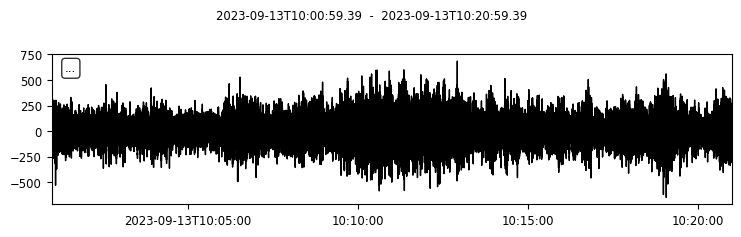

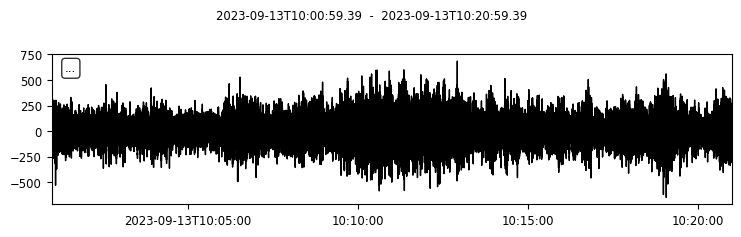

In [153]:
seg = cluster.iloc[23]
print(seg)
dt = str(seg["most_anomalous_start"])[:10]
t0 = obspy.UTCDateTime(seg["most_anomalous_start"]) - timedelta(minutes=10)
t1 = obspy.UTCDateTime(seg["most_anomalous_start"]) + timedelta(minutes=10)

st = read_segment(t0, t1, paths, filter_freq=0.3)
st.plot()

In [223]:
df

,start,stop,most_anomalous_start,scores
0,2022-12-27T02:59:10.000000Z,2022-12-27T03:12:30.000000Z,2022-12-27T03:01:40.000000Z,0.707346
1,2022-12-27T03:22:30.000000Z,2022-12-27T03:27:30.000000Z,2022-12-27T03:23:20.000000Z,0.669929
2,2022-10-17T09:21:35.350000Z,2022-10-17T09:25:45.350000Z,2022-10-17T09:22:25.350000Z,0.698063
3,2022-10-17T09:29:05.350000Z,2022-10-17T09:32:25.350000Z,2022-10-17T09:29:55.350000Z,0.696658
4,2023-10-02T15:00:09.415000Z,2023-10-02T15:05:59.415000Z,2023-10-02T15:01:49.415000Z,0.701198
5,2023-09-16T12:28:29.390000Z,2023-09-16T12:33:29.390000Z,2023-09-16T12:29:19.390000Z,0.696436
6,2023-10-16T11:44:10.000000Z,2023-10-16T11:50:00.000000Z,2023-10-16T11:44:10.000000Z,0.626829
7,2023-10-04T13:40:50.000000Z,2023-10-04T13:44:10.000000Z,2023-10-04T13:40:50.000000Z,0.605783
8,2023-10-02T05:25:50.390000Z,2023-10-02T05:28:20.390000Z,2023-10-02T05:25:50.390000Z,0.613010
9,2023-10-02T07:22:30.390000Z,2023-10-02T07:25:50.390000Z,2023-10-02T07:23:20.390000Z,0.652011


In [226]:
labs = np.array([""] * len(df), dtype=object)
remark = np.array([""] * len(df), dtype=object)

start_catalog = []
for i in range(len(df)):
    I, _, _ = iou(catalog, df.iloc[[i]].reset_index(drop=True))
    try:
        labs[i] = catalog["label"][np.where(np.append(I[0], np.diff(I)) > 0)[0]].values[
            0
        ]
        start_catalog.append(catalog.iloc[np.where(np.append(I[0], np.diff(I)) > 0)[0]])
        remark[i] = catalog["remarks"][
            np.where(np.append(I[0], np.diff(I)) > 0)[0]
        ].values[0]
    except IndexError:
        labs[i] = ""
        remark[i] = ""

# labs = np.array(labs)

start_catalog = pd.concat(start_catalog).reset_index(drop=True)
df["remarks"] = remark
df["label"] = labs

In [230]:
np.sum(labs == "CAL") / df.shape[0]

0.7142857142857143

In [227]:
df

,start,stop,most_anomalous_start,scores,remarks,label
0,2022-12-27T02:59:10.000000Z,2022-12-27T03:12:30.000000Z,2022-12-27T03:01:40.000000Z,0.707346,No Satellite Data,CAL
1,2022-12-27T03:22:30.000000Z,2022-12-27T03:27:30.000000Z,2022-12-27T03:23:20.000000Z,0.669929,No Satellite Data,CAL
2,2022-10-17T09:21:35.350000Z,2022-10-17T09:25:45.350000Z,2022-10-17T09:22:25.350000Z,0.698063,could also be rockfall,CAL
3,2022-10-17T09:29:05.350000Z,2022-10-17T09:32:25.350000Z,2022-10-17T09:29:55.350000Z,0.696658,could also be rockfall,CAL
4,2023-10-02T15:00:09.415000Z,2023-10-02T15:05:59.415000Z,2023-10-02T15:01:49.415000Z,0.701198,NaN,CAL
5,2023-09-16T12:28:29.390000Z,2023-09-16T12:33:29.390000Z,2023-09-16T12:29:19.390000Z,0.696436,dixon fjord tsunami,CAL
6,2023-10-16T11:44:10.000000Z,2023-10-16T11:50:00.000000Z,2023-10-16T11:44:10.000000Z,0.626829,NaN,TEQ
7,2023-10-04T13:40:50.000000Z,2023-10-04T13:44:10.000000Z,2023-10-04T13:40:50.000000Z,0.605783,extremely weak signal if any,N
8,2023-10-02T05:25:50.390000Z,2023-10-02T05:28:20.390000Z,2023-10-02T05:25:50.390000Z,0.613010,weak event,CAL
9,2023-10-02T07:22:30.390000Z,2023-10-02T07:25:50.390000Z,2023-10-02T07:23:20.390000Z,0.652011,weak event,CAL


In [146]:
average_seg_len = []
for cl in range(1, 14, 1):
    cluster = segments[clusters == cl]
    t0 = np.array([obspy.UTCDateTime(s) for s in cluster["start"]])
    t1 = np.array([obspy.UTCDateTime(s) for s in cluster["stop"]])
    average_seg_len.append((t1 - t0).mean() / 60 / 60)
    print(cl, average_seg_len[-1])

1 0.07385773624091381
2 0.17682421227197348
3 2.2365319865319866
4 0.10999103942652329
5 1.4647988505747127
6 0.0750534188034188
7 0.3182098765432099
8 0.061553030303030304
9 0.0668724279835391
10 10.770254629629628
11 0.04722222222222223
12 0.13541666666666666
13 8.540598290598291


In [219]:
filtered_dtc = []

for cl in [10]:
    cluster = segments[clusters == cl]

    for i in tqdm(range(len(cluster))):
        seg = cluster.iloc[i]

        dt = str(seg["most_anomalous_start"])[:10]
        t0 = obspy.UTCDateTime(seg["start"])
        t1 = obspy.UTCDateTime(seg["stop"])

        st = read_segment(t0, t1, paths, filter_freq=0.5)

        X, T = sliding_windows_from_trace(st)
        sc = -if_mod.score_samples(X)

        tr = obspy.Trace()

        tr.stats.starttime = t0
        tr.stats.sampling_rate = 0.02
        tr.data = sc

        dtc = trace_trigger_detections(tr, 0.60, 0.55)

        if len(dtc) > 0:
            for d in dtc:
                filtered_dtc.append(d)

100%|██████████| 24/24 [02:55<00:00,  7.30s/it]


In [222]:
df = pd.DataFrame(filtered_dtc)

In [ ]:
["CAL", "CAL", "CAL", "CAL", "CAL", "CAL", "TEQ", "N", "CAL", "CAL"]

In [221]:
cluster

,start,stop,most_anomalous_start,scores,control_scores,cluster,label,remarks
19,2022-12-27T02:52:30.000000Z,2022-12-27T03:35:00.000000Z,2022-12-27T03:01:40.000000Z,0.715773,0.549901,10,CAL,No Satellite Data
24,2022-10-17T09:09:55.350000Z,2022-10-17T12:50:45.350000Z,2022-10-17T09:29:55.350000Z,0.703665,0.509766,10,CAL,could also be rockfall
27,2023-10-02T14:13:29.415000Z,2023-10-02T15:45:59.415000Z,2023-10-02T15:01:49.415000Z,0.701096,0.461676,10,CAL,NaN
30,2023-09-16T12:27:39.390000Z,2023-09-16T12:49:19.390000Z,2023-09-16T12:29:19.390000Z,0.698963,0.602158,10,CAL,dixon fjord tsunami
46,2023-10-16T09:47:30.000000Z,2023-10-16T15:35:50.000000Z,2023-10-16T11:44:10.000000Z,0.675883,0.680713,10,TEQ,NaN
48,2023-10-04T13:34:10.000000Z,2023-10-04T13:51:40.000000Z,2023-10-04T13:40:50.000000Z,0.674676,0.406834,10,N,extremely weak signal if any
54,2022-12-02T10:32:29.350000Z,2022-12-02T19:21:39.350000Z,2022-12-02T18:47:29.350000Z,0.668329,0.625183,10,,
55,2023-10-01T21:40:50.390000Z,2023-10-02T13:56:40.390000Z,2023-10-02T07:23:20.390000Z,0.667713,0.446089,10,CAL,weak event
60,2022-11-03T11:18:20.000000Z,2022-11-04T09:31:40.000000Z,2022-11-04T00:03:20.000000Z,0.663683,0.492720,10,,
62,2022-12-02T19:21:42.440000Z,2022-12-03T01:07:32.440000Z,2022-12-02T19:50:02.440000Z,0.661134,0.620704,10,,


In [206]:
blue_clusters = pd.DataFrame(filtered_dtc)

In [207]:
blue_clusters.to_csv("blue_clusters.csv", index=False)

In [221]:
cl = 2
cluster = segments[clusters == cl]

In [213]:
dt = np.array([i[:10] for i in cluster["most_anomalous_start"]])

In [220]:
(np.sum(dt == "2022-09-25") + np.sum(dt == "2022-09-26")) / dt.shape[0]

0.29906542056074764

In [224]:
dt = np.array([i[:10] for i in cluster["most_anomalous_start"]])

In [231]:
np.mean(["2023-10" in i for i in dt])

0.3582089552238806

In [225]:
np.mean(dt == "2023-10-14")

0.07462686567164178

In [226]:
np.unique(dt)

array(['2022-08-22', '2022-08-24', '2022-09-02', '2022-10-10',
       '2022-10-13', '2022-10-14', '2022-10-15', '2022-10-16',
       '2022-10-18', '2022-11-03', '2022-12-02', '2022-12-03',
       '2022-12-06', '2022-12-08', '2022-12-09', '2022-12-10',
       '2022-12-14', '2022-12-15', '2022-12-17', '2022-12-24',
       '2023-09-04', '2023-09-05', '2023-09-14', '2023-09-15',
       '2023-09-26', '2023-09-28', '2023-10-01', '2023-10-02',
       '2023-10-03', '2023-10-06', '2023-10-07', '2023-10-10',
       '2023-10-11', '2023-10-12', '2023-10-13', '2023-10-14',
       '2023-10-16'], dtype='<U10')

In [235]:
cl = 7
cluster = segments[clusters == cl]

In [237]:
cluster.shape

(45, 7)

In [249]:
filtered_dtc = []

for cl in [1, 2, 7]:
    cluster = segments[clusters == cl]

    for i in tqdm(range(len(cluster))):
        seg = cluster.iloc[i]

        dt = str(seg["most_anomalous_start"])[:10]
        t0 = obspy.UTCDateTime(seg["start"])
        t1 = obspy.UTCDateTime(seg["stop"])

        st = read_segment(t0, t1, paths, filter_freq=0.5)

        X, T = sliding_windows_from_trace(st)
        sc = -if_mod.score_samples(X)

        tr = obspy.Trace()

        tr.stats.starttime = t0
        tr.stats.sampling_rate = 0.02
        tr.data = sc

        dtc = trace_trigger_detections(tr, 0.60, 0.55)

        if len(dtc) > 0:
            for d in dtc:
                filtered_dtc.append(d)

  0%|          | 0/107 [00:00<?, ?it/s]c:\Users\franc\anaconda3\envs\seismic-if-env\lib\site-packages\obspy\core\trace.py:1755: UserWarning: Resampled trace would have less than one sample. Retaining exactly one sample.
  warnings.warn(msg)
  1%|          | 1/107 [00:02<05:14,  2.96s/it]c:\Users\franc\anaconda3\envs\seismic-if-env\lib\site-packages\obspy\core\trace.py:1755: UserWarning: Resampled trace would have less than one sample. Retaining exactly one sample.
  warnings.warn(msg)
  2%|▏         | 2/107 [00:05<05:05,  2.91s/it]c:\Users\franc\anaconda3\envs\seismic-if-env\lib\site-packages\obspy\core\trace.py:1755: UserWarning: Resampled trace would have less than one sample. Retaining exactly one sample.
  warnings.warn(msg)
  3%|▎         | 3/107 [00:08<04:57,  2.86s/it]c:\Users\franc\anaconda3\envs\seismic-if-env\lib\site-packages\obspy\core\trace.py:1755: UserWarning: Resampled trace would have less than one sample. Retaining exactly one sample.
  warnings.warn(msg)
  4%|▎      

In [250]:
filtered_dtc

[]

In [242]:
filtered_dtc

[]

In [243]:
cluster

,start,stop,most_anomalous_start,scores,control_scores,cluster,label
196,2022-12-14T12:50:50.000000Z,2022-12-14T13:07:30.000000Z,2022-12-14T12:50:50.000000Z,0.626701,0.531858,7,
227,2022-10-18T11:24:05.350000Z,2022-10-18T11:45:45.350000Z,2022-10-18T11:24:55.350000Z,0.623153,0.565905,7,CAL
231,2023-10-16T15:41:40.000000Z,2023-10-16T15:57:30.000000Z,2023-10-16T15:49:10.000000Z,0.622793,0.626705,7,N
233,2023-09-27T15:31:40.390000Z,2023-09-27T15:50:00.390000Z,2023-09-27T15:34:10.390000Z,0.622594,0.544447,7,
280,2023-10-14T04:55:00.000000Z,2023-10-14T05:16:40.000000Z,2023-10-14T04:55:00.000000Z,0.617914,0.600276,7,
289,2023-10-13T10:58:20.000000Z,2023-10-13T11:18:20.000000Z,2023-10-13T10:58:20.000000Z,0.617419,0.530458,7,
291,2023-10-13T09:39:10.000000Z,2023-10-13T09:55:00.000000Z,2023-10-13T09:40:00.000000Z,0.617166,0.516785,7,
305,2023-01-01T06:54:10.000000Z,2023-01-01T07:10:50.000000Z,2023-01-01T06:54:10.000000Z,0.616162,0.525588,7,
309,2023-10-16T08:10:50.000000Z,2023-10-16T08:30:50.000000Z,2023-10-16T08:13:20.000000Z,0.615766,0.564364,7,
317,2022-10-14T12:41:35.350000Z,2022-10-14T13:01:35.350000Z,2022-10-14T12:48:15.350000Z,0.615216,0.504613,7,


In [ ]:
seg = cluster.iloc[23]
print(seg)


st = read_segment(t0, t1, paths, filter_freq=0.7)
st.plot()

In [537]:
sizes = [len(segments[clusters == cl]) for cl in np.unique(clusters)]

In [ ]:
red_clusters = pd.concat(
    [segments[clusters == 6], segments[clusters == 8], segments[clusters == 9]]
).reset_index(drop=True)
red_clusters.to_csv("red_clusters.csv")

In [498]:
updated_scores = []
for cl in range(1, 14, 1):
    cluster = segments[clusters == cl]

    labs = np.repeat("   ", len(cluster))
    for i in range(len(cluster)):
        I, _, _ = iou(catalog, cluster.iloc[[i]].reset_index(drop=True))
        try:
            labs[i] = catalog["label"][
                np.where(np.append(I[0], np.diff(I)) > 0)[0]
            ].values[0]
        except IndexError:
            labs[i] = "   "
    cluster.loc[:, "label"] = labs

    new_scores = []
    for i in tqdm(range(len(cluster))):
        _, _, t0, t1 = limit_segment_length(
            cluster["start"].iloc[i], cluster["stop"].iloc[i], paths, if_mod
        )
        seg = read_segment(t0, t1, paths)
        seg.filter("highpass", freq=0.5, zerophase=True)
        X, _ = sliding_windows_from_trace(seg)
        new_scores.append(np.max(-if_mod.score_samples(X)))

    updated_scores.append(np.array(new_scores))

  0%|          | 0/107 [00:00<?, ?it/s]c:\Users\franc\anaconda3\envs\seismic-if-env\lib\site-packages\obspy\core\trace.py:1755: UserWarning: Resampled trace would have less than one sample. Retaining exactly one sample.
  warnings.warn(msg)
c:\Users\franc\anaconda3\envs\seismic-if-env\lib\site-packages\obspy\core\trace.py:1755: UserWarning: Resampled trace would have less than one sample. Retaining exactly one sample.
  warnings.warn(msg)
  1%|          | 1/107 [00:05<10:16,  5.81s/it]c:\Users\franc\anaconda3\envs\seismic-if-env\lib\site-packages\obspy\core\trace.py:1755: UserWarning: Resampled trace would have less than one sample. Retaining exactly one sample.
  warnings.warn(msg)
c:\Users\franc\anaconda3\envs\seismic-if-env\lib\site-packages\obspy\core\trace.py:1755: UserWarning: Resampled trace would have less than one sample. Retaining exactly one sample.
  warnings.warn(msg)
  2%|▏         | 2/107 [00:11<10:14,  5.86s/it]c:\Users\franc\anaconda3\envs\seismic-if-env\lib\site-packa

In [ ]:
df.iloc[np.flip(np.argsort([np.mean(i) for i in updated_scores]))]

,unknown,EQ,MM,N
cluster,,,,
13,0.000000,0.000000,0.000000,1.000000
12,0.000000,0.000000,1.000000,0.000000
8,0.022727,0.000000,0.863636,0.113636
11,0.000000,0.000000,0.050000,0.950000
9,0.037037,0.000000,0.962963,0.000000
10,0.750000,0.041667,0.208333,0.000000
6,0.038462,0.865385,0.038462,0.057692
4,1.000000,0.000000,0.000000,0.000000
5,0.982759,0.000000,0.017241,0.000000


In [524]:
np.array([np.mean(i) for i in updated_scores])

array([0.50330217, 0.49392654, 0.51840738, 0.54227255, 0.52194025,
       0.56670064, 0.49309774, 0.63293547, 0.59522938, 0.58918174,
       0.63137331, 0.66309278, 0.73040412])

In [525]:
cl = 10
cluster = segments[clusters == cl]

labs = np.repeat("   ", len(cluster))
for i in range(len(cluster)):
    I, _, _ = iou(catalog, cluster.iloc[[i]].reset_index(drop=True))
    try:
        labs[i] = catalog["label"][np.where(np.append(I[0], np.diff(I)) > 0)[0]].values[
            0
        ]
    except IndexError:
        labs[i] = "   "
cluster.loc[:, "label"] = labs

In [531]:
updated_scores[10]

array([0.70853651, 0.69975523, 0.66430129, 0.65898596, 0.65932015,
       0.6414138 , 0.64675173, 0.62359562, 0.62005614, 0.62234748,
       0.63474245, 0.6148551 , 0.6217291 , 0.62173441, 0.61579635,
       0.59247706, 0.6022048 , 0.60065134, 0.60504515, 0.57316646])

In [526]:
cluster

,start,stop,most_anomalous_start,scores,control_scores,cluster,label
19,2022-12-27T02:52:30.000000Z,2022-12-27T03:35:00.000000Z,2022-12-27T03:01:40.000000Z,0.715773,0.549901,10,CAL
24,2022-10-17T09:09:55.350000Z,2022-10-17T12:50:45.350000Z,2022-10-17T09:29:55.350000Z,0.703665,0.509766,10,CAL
27,2023-10-02T14:13:29.415000Z,2023-10-02T15:45:59.415000Z,2023-10-02T15:01:49.415000Z,0.701096,0.461676,10,CAL
30,2023-09-16T12:27:39.390000Z,2023-09-16T12:49:19.390000Z,2023-09-16T12:29:19.390000Z,0.698963,0.602158,10,CAL
46,2023-10-16T09:47:30.000000Z,2023-10-16T15:35:50.000000Z,2023-10-16T11:44:10.000000Z,0.675883,0.680713,10,TEQ
48,2023-10-04T13:34:10.000000Z,2023-10-04T13:51:40.000000Z,2023-10-04T13:40:50.000000Z,0.674676,0.406834,10,
54,2022-12-02T10:32:29.350000Z,2022-12-02T19:21:39.350000Z,2022-12-02T18:47:29.350000Z,0.668329,0.625183,10,
55,2023-10-01T21:40:50.390000Z,2023-10-02T13:56:40.390000Z,2023-10-02T07:23:20.390000Z,0.667713,0.446089,10,
60,2022-11-03T11:18:20.000000Z,2022-11-04T09:31:40.000000Z,2022-11-04T00:03:20.000000Z,0.663683,0.492720,10,
62,2022-12-02T19:21:42.440000Z,2022-12-03T01:07:32.440000Z,2022-12-02T19:50:02.440000Z,0.661134,0.620704,10,


In [501]:
updated_scores[3]

array([0.5608656 , 0.53486457, 0.55112288, 0.62309946, 0.54530973,
       0.54722146, 0.52791031, 0.5455664 , 0.56235666, 0.54888796,
       0.54424617, 0.54034928, 0.55164961, 0.54462461, 0.54319204,
       0.54901233, 0.54897005, 0.54031477, 0.5568348 , 0.52971414,
       0.53742268, 0.54319093, 0.54092398, 0.53452023, 0.57006882,
       0.54290189, 0.55084198, 0.53767957, 0.54619257, 0.54242237,
       0.54669947, 0.54693049, 0.5484896 , 0.55319852, 0.54843184,
       0.53884714, 0.54066177, 0.54128762, 0.57938739, 0.54029269,
       0.53568676, 0.53896773, 0.53619385, 0.53628181, 0.5324874 ,
       0.54087183, 0.54242851, 0.55279563, 0.54130627, 0.52592434,
       0.5389729 , 0.54188788, 0.5401998 , 0.53405581, 0.50555139,
       0.53172515, 0.52398193, 0.51929613, 0.52064418, 0.52119355,
       0.51840702, 0.51553371])

In [ ]:
lens = []
for i in range(len(cluster)):
    t0 = obspy.UTCDateTime(cluster["start"].iloc[i])
    t1 = obspy.UTCDateTime(cluster["stop"].iloc[i])
    lens.append(t1 - t0)

print(cluster.shape)
print(np.mean(lens) / 60 / 60)

In [491]:
# days = [i[:10] for i in cluster["start"]]
# unique_days = np.unique(days)

# for day in unique_days:
#     print(day,np.mean(np.array(days) == day))

# cluster.to_csv("cluster_4.csv", index=False)

In [379]:
cl = 3
cluster = segments[clusters == cl]

labs = np.repeat("   ", len(cluster))
for i in range(len(cluster)):
    I, _, _ = iou(catalog, cluster.iloc[[i]].reset_index(drop=True))
    try:
        labs[i] = catalog["label"][np.where(np.append(I[0], np.diff(I)) > 0)[0]].values[
            0
        ]
    except IndexError:
        labs[i] = "   "
cluster.loc[:, "label"] = labs

In [380]:
lens = []
for i in range(len(cluster)):
    t0 = obspy.UTCDateTime(cluster["start"].iloc[i])
    t1 = obspy.UTCDateTime(cluster["stop"].iloc[i])
    lens.append(t1 - t0)

print(cluster.shape)
print(np.mean(lens) / 60 / 60)

(66, 7)
2.2365319865319866


In [399]:
new_scores = []
for i in tqdm(range(len(cluster))):
    _, _, t0, t1 = limit_segment_length(
        cluster["start"].iloc[i], cluster["stop"].iloc[i], paths, if_mod
    )
    seg = read_segment(t0, t1, paths)
    seg.filter("highpass", freq=1.0, zerophase=True)
    X, _ = sliding_windows_from_trace(seg)
    new_scores.append(np.max(-if_mod.score_samples(X)))

print(np.mean(np.array(new_scores) > 0.60))

100%|██████████| 66/66 [06:40<00:00,  6.07s/it]

0.0


In [307]:
cl = 4
cluster = segments[clusters == cl]

In [308]:
labs = np.repeat("   ", len(cluster))
for i in range(len(cluster)):
    I, _, _ = iou(catalog, cluster.iloc[[i]].reset_index(drop=True))
    try:
        labs[i] = catalog["label"][np.where(np.append(I[0], np.diff(I)) > 0)[0]].values[
            0
        ]
    except IndexError:
        labs[i] = "   "
cluster.loc[:, "label"] = labs

In [320]:
days = [i[:10] for i in cluster["start"]]
unique_days = np.unique(days)

for day in unique_days:
    print(np.mean(np.array(days) == day))

cluster.to_csv("cluster_4.csv", index=False)

st = obspy.read(find_date_in_strings(paths, "2022-09-25")[0])
print(len(st))

0.9516129032258065
0.016129032258064516
0.016129032258064516
0.016129032258064516
199


In [400]:
cl = 5
cluster = segments[clusters == cl]

labs = np.repeat("   ", len(cluster))
for i in range(len(cluster)):
    I, _, _ = iou(catalog, cluster.iloc[[i]].reset_index(drop=True))
    try:
        labs[i] = catalog["label"][np.where(np.append(I[0], np.diff(I)) > 0)[0]].values[
            0
        ]
    except IndexError:
        labs[i] = "   "
cluster.loc[:, "label"] = labs

In [401]:
lens = []
for i in range(len(cluster)):
    t0 = obspy.UTCDateTime(cluster["start"].iloc[i])
    t1 = obspy.UTCDateTime(cluster["stop"].iloc[i])
    lens.append(t1 - t0)

print(cluster.shape)
print(np.mean(lens) / 60 / 60)

(58, 7)
1.4647988505747127


In [432]:
new_scores = []
for i in tqdm(range(len(cluster))):
    _, _, t0, t1 = limit_segment_length(
        cluster["start"].iloc[i], cluster["stop"].iloc[i], paths, if_mod
    )
    seg = read_segment(t0, t1, paths)
    seg.filter("highpass", freq=1.0, zerophase=True)
    X, _ = sliding_windows_from_trace(seg)
    new_scores.append(np.max(-if_mod.score_samples(X)))

print(np.mean(np.array(new_scores) > 0.60))

  0%|          | 0/107 [00:00<?, ?it/s]c:\Users\franc\anaconda3\envs\seismic-if-env\lib\site-packages\obspy\core\trace.py:1755: UserWarning: Resampled trace would have less than one sample. Retaining exactly one sample.
  warnings.warn(msg)
c:\Users\franc\anaconda3\envs\seismic-if-env\lib\site-packages\obspy\core\trace.py:1755: UserWarning: Resampled trace would have less than one sample. Retaining exactly one sample.
  warnings.warn(msg)
  1%|          | 1/107 [00:05<10:09,  5.75s/it]c:\Users\franc\anaconda3\envs\seismic-if-env\lib\site-packages\obspy\core\trace.py:1755: UserWarning: Resampled trace would have less than one sample. Retaining exactly one sample.
  warnings.warn(msg)
  1%|          | 1/107 [00:08<14:18,  8.10s/it]


KeyboardInterrupt: 

In [147]:
if_mod = joblib.load(f"../output/{network}/if/models/{station}.joblib")

In [148]:
cluster = cluster.reset_index(drop=True)

In [149]:
cluster_segments = []
for i in tqdm(range(len(cluster))):
    cluster_segments.append(
        limit_segment_length(cluster["start"][i], cluster["stop"][i], paths, if_mod)
    )

100%|██████████| 58/58 [02:37<00:00,  2.71s/it]


In [155]:
for i in tqdm(range(len(cluster_segments))):
    t0 = cluster_segments[i][2]
    t1 = cluster_segments[i][3]
    cluster_segments[i] = read_segment(t0, t1, paths)

100%|██████████| 58/58 [02:06<00:00,  2.19s/it]


In [294]:
red_clusters.iloc[np.where(red_clusters["label"] == "   ")[0]]

,start,stop,most_anomalous_start,scores,control_scores,cluster,label
47,2022-12-01T14:39:09.350000Z,2022-12-01T14:42:29.350000Z,2022-12-01T14:39:09.350000Z,0.604487,0.669423,6,
48,2022-10-20T23:45:45.350000Z,2022-10-20T23:49:55.350000Z,2022-10-20T23:45:45.350000Z,0.603499,0.509262,6,
88,2022-08-15T22:15:04.845000Z,2022-08-15T22:17:34.845000Z,2022-08-15T22:15:04.845000Z,0.605664,0.402438,8,
96,2022-11-01T04:47:30.000000Z,2022-11-01T04:51:40.000000Z,2022-11-01T04:48:20.000000Z,0.656864,0.448086,9,


In [15]:
cl = 10
cluster = segments[clusters == cl]

In [16]:
cluster

,start,stop,most_anomalous_start,scores,control_scores,cluster,label
19,2022-12-27T02:52:30.000000Z,2022-12-27T03:35:00.000000Z,2022-12-27T03:01:40.000000Z,0.715773,0.549901,10,CAL
24,2022-10-17T09:09:55.350000Z,2022-10-17T12:50:45.350000Z,2022-10-17T09:29:55.350000Z,0.703665,0.509766,10,CAL
27,2023-10-02T14:13:29.415000Z,2023-10-02T15:45:59.415000Z,2023-10-02T15:01:49.415000Z,0.701096,0.461676,10,CAL
30,2023-09-16T12:27:39.390000Z,2023-09-16T12:49:19.390000Z,2023-09-16T12:29:19.390000Z,0.698963,0.602158,10,CAL
46,2023-10-16T09:47:30.000000Z,2023-10-16T15:35:50.000000Z,2023-10-16T11:44:10.000000Z,0.675883,0.680713,10,TEQ
48,2023-10-04T13:34:10.000000Z,2023-10-04T13:51:40.000000Z,2023-10-04T13:40:50.000000Z,0.674676,0.406834,10,
54,2022-12-02T10:32:29.350000Z,2022-12-02T19:21:39.350000Z,2022-12-02T18:47:29.350000Z,0.668329,0.625183,10,
55,2023-10-01T21:40:50.390000Z,2023-10-02T13:56:40.390000Z,2023-10-02T07:23:20.390000Z,0.667713,0.446089,10,
60,2022-11-03T11:18:20.000000Z,2022-11-04T09:31:40.000000Z,2022-11-04T00:03:20.000000Z,0.663683,0.492720,10,
62,2022-12-02T19:21:42.440000Z,2022-12-03T01:07:32.440000Z,2022-12-02T19:50:02.440000Z,0.661134,0.620704,10,


start                   2022-09-09T04:58:20.350000Z
stop                    2022-09-09T05:00:50.350000Z
most_anomalous_start    2022-09-09T04:58:20.350000Z
scores                                     0.614313
Name: 0, dtype: object


c:\Users\franc\anaconda3\envs\seismic-if-env\lib\site-packages\obspy\imaging\util.py:266: UserWarning: AutoDateLocator was unable to pick an appropriate interval for this date range. It may be necessary to add an interval value to the AutoDateLocator's intervald dictionary. Defaulting to 30.
  plt.setp(ax.get_xticklabels(), fontsize='small')
c:\Users\franc\anaconda3\envs\seismic-if-env\lib\site-packages\obspy\imaging\waveform.py:815: UserWarning: AutoDateLocator was unable to pick an appropriate interval for this date range. It may be necessary to add an interval value to the AutoDateLocator's intervald dictionary. Defaulting to 30.
  plt.setp(ax.get_xticklabels(), fontsize='small',


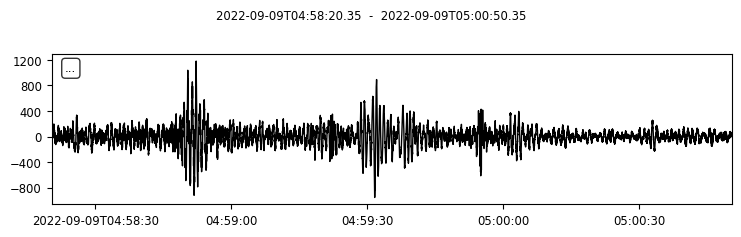

0.6143129800455907

In [184]:
seg = cluster.iloc[0]
print(seg)
dt = str(seg["most_anomalous_start"])[:10]
t0 = obspy.UTCDateTime(seg["start"])
t1 = obspy.UTCDateTime(seg["stop"])

st = read_segment(t0, t1, paths, filter_freq=0.7)
st.plot()
X = sliding_windows_from_trace(st)[0]
np.max(-if_mod.score_samples(X))

c:\Users\franc\anaconda3\envs\seismic-if-env\lib\site-packages\obspy\imaging\util.py:266: UserWarning: AutoDateLocator was unable to pick an appropriate interval for this date range. It may be necessary to add an interval value to the AutoDateLocator's intervald dictionary. Defaulting to 30.
  plt.setp(ax.get_xticklabels(), fontsize='small')
c:\Users\franc\anaconda3\envs\seismic-if-env\lib\site-packages\obspy\imaging\waveform.py:815: UserWarning: AutoDateLocator was unable to pick an appropriate interval for this date range. It may be necessary to add an interval value to the AutoDateLocator's intervald dictionary. Defaulting to 30.
  plt.setp(ax.get_xticklabels(), fontsize='small',


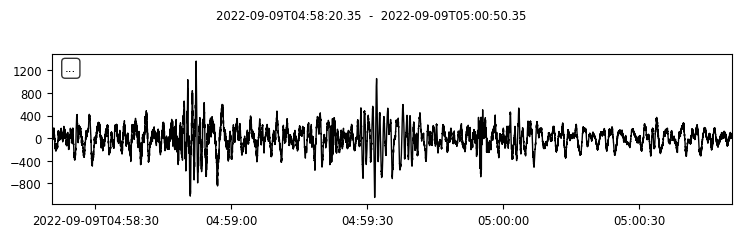

0.6351057971797751

In [185]:
st = read_segment(t0, t1, paths)
st.plot()
X = sliding_windows_from_trace(st)[0]
np.max(-if_mod.score_samples(X))

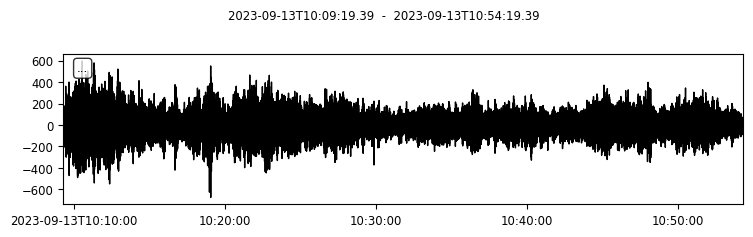

0.598344258264474

In [136]:
st = read_segment(t0, t1, paths, filter_freq=0.7)
st.plot()
X = sliding_windows_from_trace(st)[0]
np.max(-if_mod.score_samples(X))

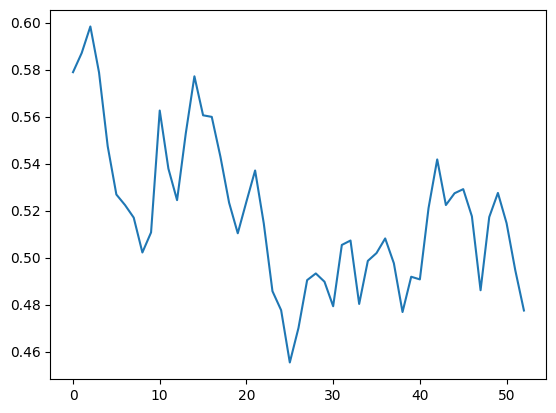

In [137]:
plt.plot(-if_mod.score_samples(X))

In [138]:
t0 = obspy.UTCDateTime(seg["most_anomalous_start"]) - timedelta(minutes=4)
t1 = obspy.UTCDateTime(seg["most_anomalous_start"]) + timedelta(minutes=4)
st = read_segment(t0, t1, paths, filter_freq=0.7)

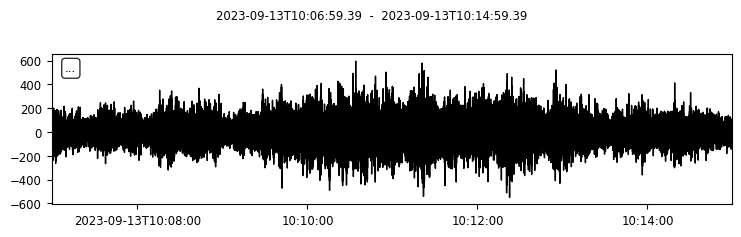

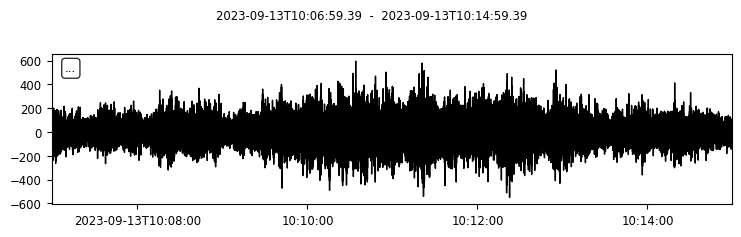

In [139]:
st.plot()

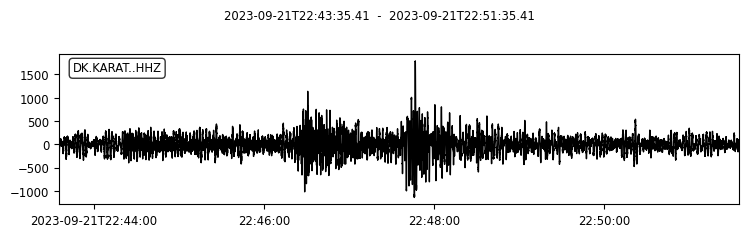

In [89]:
st = obspy.read(find_date_in_strings(paths, dt)[0])
preproc_stream(st, filter_freq=0.3)
st.trim(t0, t1)
st.plot()
plt.show()

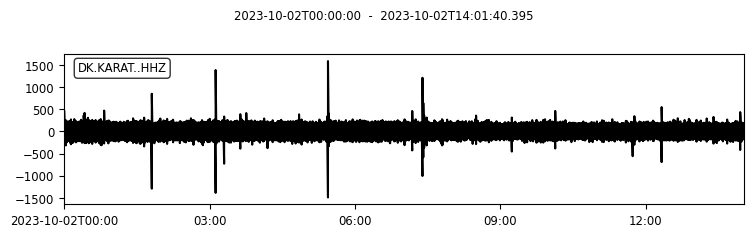

0.6623916542875737

In [88]:
st = obspy.read(find_date_in_strings(paths, dt)[0])
preproc_stream(st, filter_freq=0.5)
st.trim(t0, t1)
st.plot()
plt.show()

X = sliding_windows_from_stream(st)[0]
np.max(-if_mod.score_samples(X))

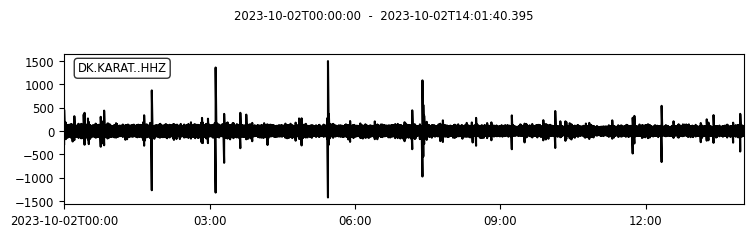

0.6528908757144588

In [89]:
st = obspy.read(find_date_in_strings(paths, dt)[0])
preproc_stream(st, filter_freq=0.7)
st.trim(t0, t1)
st.plot()
plt.show()

X = sliding_windows_from_stream(st)[0]
np.max(-if_mod.score_samples(X))

array([-0.36534229, -0.36782591, -0.3688285 , -0.37720681, -0.3891983 ,
       -0.38958359, -0.39554084, -0.39053446, -0.39026087, -0.39221599,
       -0.38724844, -0.39275358, -0.39658607, -0.40540373, -0.4115181 ,
       -0.40798801, -0.40030437, -0.4033979 , -0.40020474, -0.40325791,
       -0.42785121, -0.46451142, -0.49433412, -0.4687261 , -0.43868617,
       -0.4189674 , -0.41131606, -0.41738498, -0.39987173, -0.37941921,
       -0.37726231, -0.37806728])

In [279]:
seg = cluster.loc[84]
print(seg)
dt = str(seg["most_anomalous_start"])[:10]
t0 = obspy.UTCDateTime(seg["start"]) - timedelta(minutes=5)
t1 = obspy.UTCDateTime(seg["stop"]) + timedelta(minutes=5)

start                   2022-09-22T09:09:37.390000Z
stop                    2022-09-22T09:11:17.390000Z
most_anomalous_start    2022-09-22T09:09:37.390000Z
scores                                     0.608948
control_scores                             0.481111
cluster                                           8
label                                           CAL
Name: 84, dtype: object


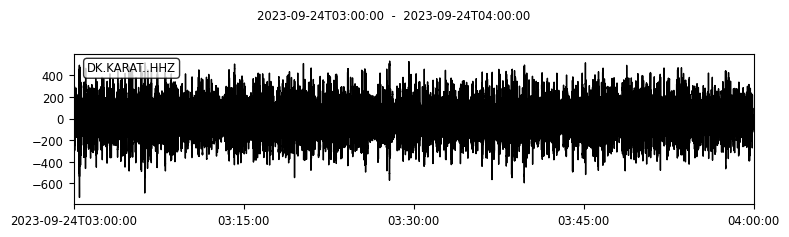

In [280]:
st1 = obspy.read(find_date_in_strings(paths, "2023-09-24")[0])
preproc_stream(st1)
t0 = obspy.UTCDateTime("2023-09-24T03:00:00.000000Z")
t1 = obspy.UTCDateTime("2023-09-24T04:00:00.000000Z")
st1.trim(t0, t1)
st1.plot()
plt.show()

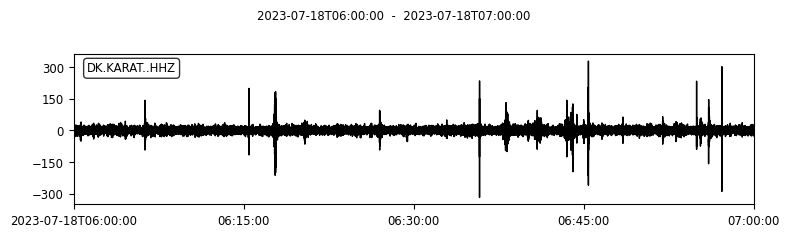

In [220]:
st2 = obspy.read(find_date_in_strings(paths, "2023-07-18")[0])
preproc_stream(st2)
t0 = obspy.UTCDateTime("2023-07-18T06:00:00")
t1 = obspy.UTCDateTime("2023-07-18T07:00:00")
st2.trim(t0, t1)
st2.plot()
plt.show()

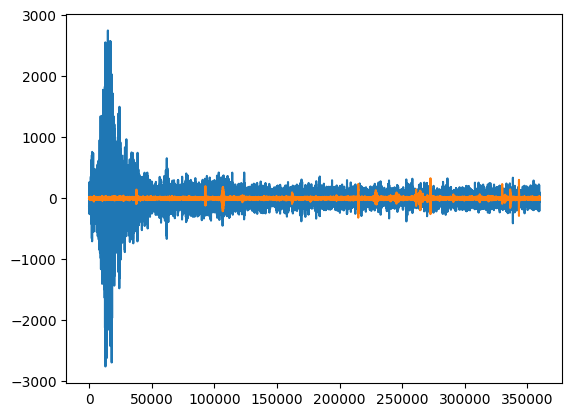

In [211]:
plt.plot(st1[0].data)
plt.plot(st2[0].data)

In [221]:
from scipy.signal import welch

fs = 100  # Example sampling frequency, replace with actual value
x = st1[0].data  # Example data, replace with actual data
f, psd1 = welch(x, fs, nperseg=1024)

fs = 100  # Example sampling frequency, replace with actual value
x = st2[0].data  # Example data, replace with actual data
f, psd2 = welch(x, fs, nperseg=1024)

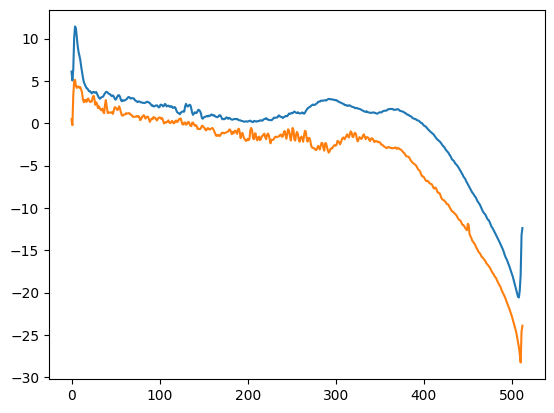

In [222]:
plt.plot(np.log(psd1))
plt.plot(np.log(psd2))

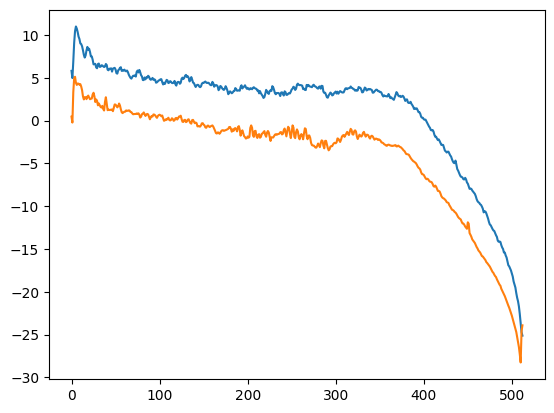

In [213]:
plt.plot(np.log(psd1))
plt.plot(np.log(psd2))

In [201]:
np.argmax(psd1)

5

In [198]:
psds = []

for x in cluster_segments:
    f, psd = welch(x.data, fs, nperseg=1024)
    psds.append(psd)

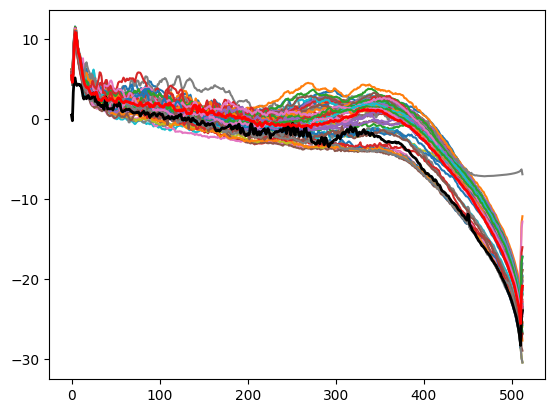

In [174]:
for x in psds:
    plt.plot(np.log(x))

plt.plot(np.log(psd2), c="k", linewidth=2)
plt.plot(np.log(psds[38]), c="r", linewidth=2)

In [39]:
st

1 Trace(s) in Stream:
DK.KARAT..HHZ | 2022-09-25T20:11:26.405000Z - 2022-09-25T20:16:26.405000Z | 100.0 Hz, 30001 samples

In [923]:
st = obspy.read(paths[0])
current_tr = st[0]

gaps = []

for i in range(1, len(paths)):
    st = obspy.read(paths[i])

    for tr in st:
        if (
            current_tr.stats.endtime
            + timedelta(seconds=1 / current_tr.stats.sampling_rate)
            < tr.stats.starttime
        ):
            gaps.append(current_tr.stats.endtime)

        current_tr = tr

In [22]:
cl = 1
cluster = segments[clusters == cl]
arr = np.array([i[:10] for i in cluster["start"]])

values, counts = np.unique(arr, return_counts=True)
rel_freq = counts / counts.sum()

result = dict(zip(values, rel_freq))
print(result)

{'2022-09-02': 0.018691588785046728, '2022-09-11': 0.009345794392523364, '2022-09-25': 0.16822429906542055, '2022-09-26': 0.1308411214953271, '2022-10-13': 0.009345794392523364, '2022-10-14': 0.028037383177570093, '2022-10-18': 0.028037383177570093, '2022-10-20': 0.018691588785046728, '2022-11-02': 0.018691588785046728, '2022-11-03': 0.028037383177570093, '2022-11-09': 0.018691588785046728, '2022-11-13': 0.009345794392523364, '2022-11-15': 0.009345794392523364, '2022-12-02': 0.009345794392523364, '2022-12-04': 0.018691588785046728, '2022-12-07': 0.028037383177570093, '2022-12-08': 0.018691588785046728, '2022-12-09': 0.028037383177570093, '2022-12-10': 0.009345794392523364, '2022-12-14': 0.018691588785046728, '2022-12-15': 0.009345794392523364, '2022-12-24': 0.102803738317757, '2023-03-04': 0.009345794392523364, '2023-08-21': 0.018691588785046728, '2023-09-05': 0.028037383177570093, '2023-09-15': 0.018691588785046728, '2023-09-21': 0.009345794392523364, '2023-09-22': 0.00934579439252336

In [16]:
cl = 1
cluster = segments[clusters == cl]
arr = np.array([i[:10] for i in cluster["start"]])

values, counts = np.unique(arr, return_counts=True)
rel_freq = counts / counts.sum()

result = dict(zip(values, rel_freq))
print(pd.DataFrame(result, index=[0]).T)

                   0
2022-09-02  0.018692
2022-09-11  0.009346
2022-09-25  0.168224
2022-09-26  0.130841
2022-10-13  0.009346
2022-10-14  0.028037
2022-10-18  0.028037
2022-10-20  0.018692
2022-11-02  0.018692
2022-11-03  0.028037
2022-11-09  0.018692
2022-11-13  0.009346
2022-11-15  0.009346
2022-12-02  0.009346
2022-12-04  0.018692
2022-12-07  0.028037
2022-12-08  0.018692
2022-12-09  0.028037
2022-12-10  0.009346
2022-12-14  0.018692
2022-12-15  0.009346
2022-12-24  0.102804
2023-03-04  0.009346
2023-08-21  0.018692
2023-09-05  0.028037
2023-09-15  0.018692
2023-09-21  0.009346
2023-09-22  0.009346
2023-09-23  0.009346
2023-09-24  0.028037
2023-10-01  0.018692
2023-10-02  0.018692
2023-10-03  0.009346
2023-10-10  0.009346
2023-10-12  0.009346
2023-10-13  0.037383
2023-10-14  0.018692
2023-10-15  0.009346


In [ ]:
# cl = 4
# cluster = pd.concat([cluster, segments[clusters == cl]])

{'2022-09-25': 0.9516129032258065, '2022-12-24': 0.016129032258064516, '2022-12-25': 0.016129032258064516, '2023-10-06': 0.016129032258064516}


In [974]:
cluster_t0 = cluster["start"].values
cluster_t0 = [obspy.UTCDateTime(i) for i in cluster_t0]

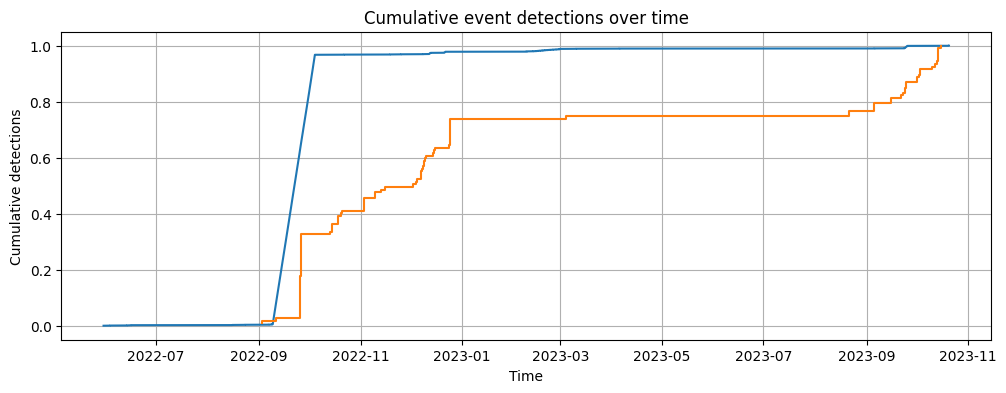

In [975]:
times = np.array(gaps)

# 1. sort the timestamps
times_sorted = np.sort(times)

# 2. convert to Python datetime for plotting
times_dt = [t.datetime for t in times_sorted]

# 3. cumulative counts
counts1 = np.arange(1, len(times_dt) + 1) / len(times_dt)

# 4. plot
plt.figure(figsize=(12, 4))
plt.step(times_dt, counts1, where="post")  # step plot is ideal
plt.xlabel("Time")
plt.ylabel("Cumulative detections")
plt.title("Cumulative event detections over time")

times = np.array(cluster_t0)
times_sorted = np.sort(times)
times_dt = [t.datetime for t in times_sorted]
counts = np.arange(1, len(times_dt) + 1) / len(times_dt)
plt.step(times_dt, counts, where="post")


plt.grid()

plt.show()

In [27]:
if_model

NameError: name 'if_model' is not defined

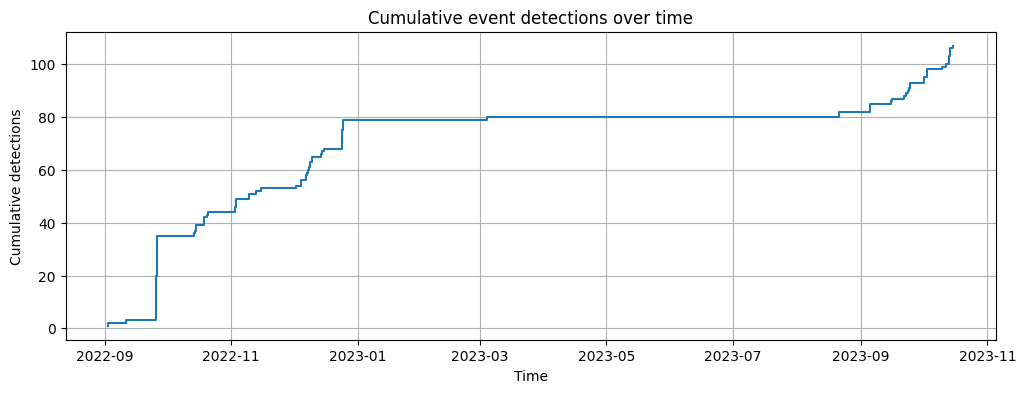

In [ ]:
plt.figure(figsize=(12, 4))
plt.step(times_dt, counts, where="post")  # step plot is ideal
plt.xlabel("Time")
plt.ylabel("Cumulative detections")
plt.title("Cumulative event detections over time")
plt.grid()

plt.show()

In [330]:
# 2023-10-14T03:55:00.000000Z,2023-10-14T04:09:10.000000Z,N,extremely weak signal if any

In [863]:
t0 = obspy.UTCDateTime("2023-10-14T03:55:00.000000Z")
t1 = obspy.UTCDateTime("2023-10-14T04:09:10.000000Z")
st = obspy.read(find_date_in_strings(paths, "2023-10-14")[0])
preproc_stream(st)
st.trim(t0, t1)
x = st[0].data.copy()

t0 = obspy.UTCDateTime("2022-11-24T03:55:00.000000Z")
t1 = obspy.UTCDateTime("2022-11-24T04:09:10.000000Z")
st = obspy.read(find_date_in_strings(paths, "2022-11-24")[0])
preproc_stream(st)
st.trim(t0, t1)
y = st[0].data.copy()

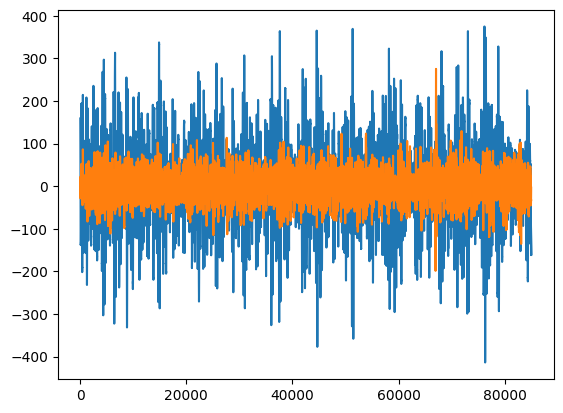

In [864]:
plt.plot(x)
plt.plot(y)

[<Figure size 640x480 with 1 Axes>]

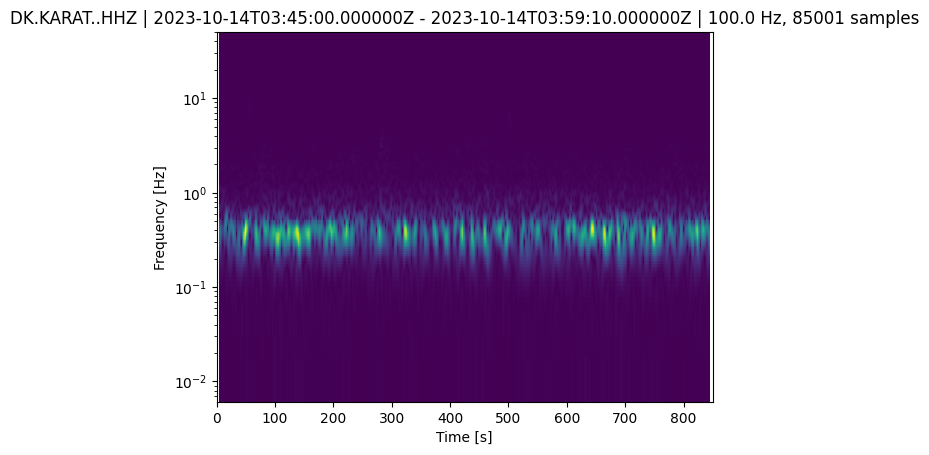

In [335]:
st.spectrogram(log=True, wlen=10, show=False)

In [316]:
stt = st.copy()

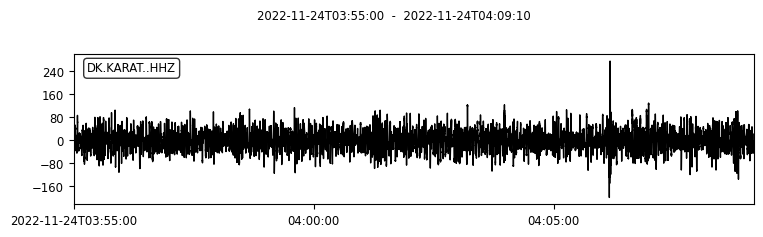

In [338]:
y = st[0].data.copy()

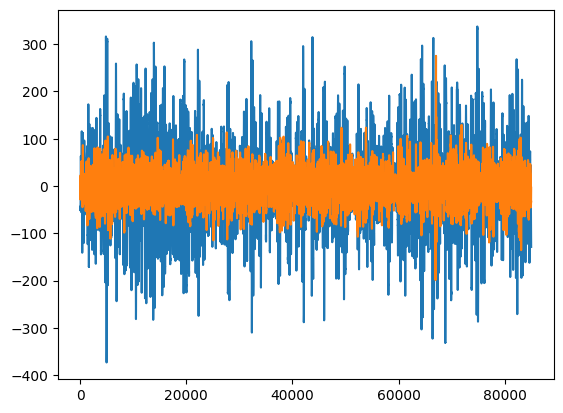

In [318]:
st = st + stt

[<Figure size 640x480 with 1 Axes>, <Figure size 640x480 with 1 Axes>]

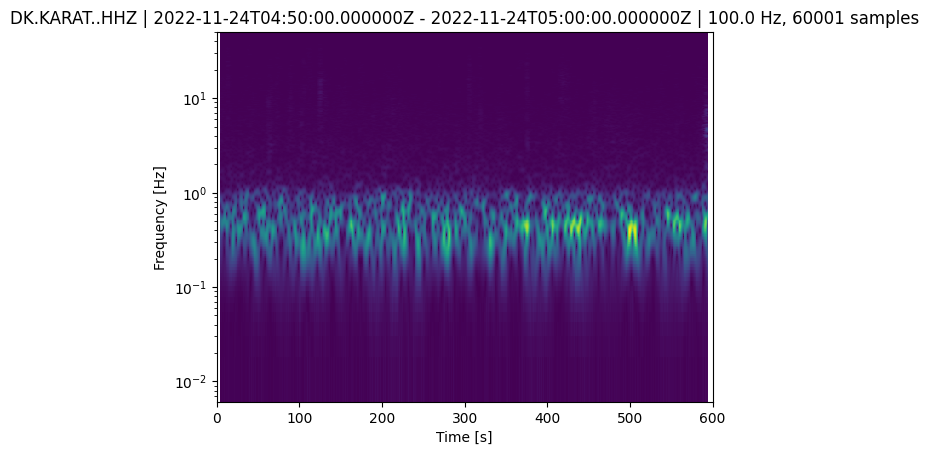

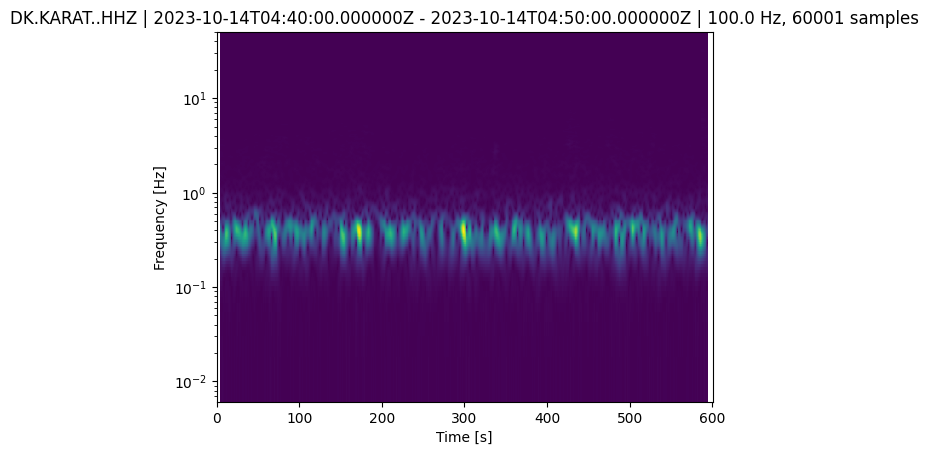

In [319]:
st.spectrogram(log=True, wlen=10, show=False)

In [295]:
preproc_stream(st)

1 Trace(s) in Stream:
DK.KARAT..HHZ | 2022-11-24T00:00:00.000000Z - 2022-11-24T23:59:59.990000Z | 100.0 Hz, 8640000 samples

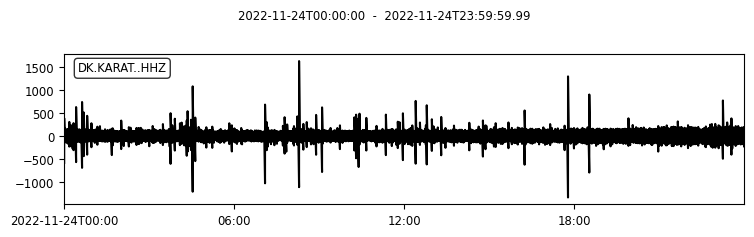

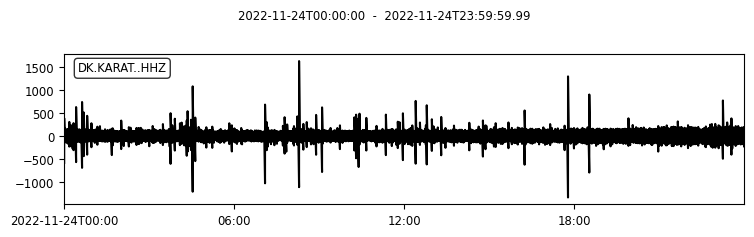

### New KARAT

In [388]:
station = "KARAT"
network = "DK"
karat_paths = paths = find_paths("DK", "KARAT", "HHZ.D", start=2022, stop=2023)

catalog = pd.read_csv("../catalogs/DK/KARAT.csv")
catalog = preproc_flow_annotations(catalog)
segments = pd.read_csv(f"../output/{network}/if/segments/{station}.csv", index_col=0)

dtw_path = f"../output/{network}/dtw/distances"

with open(f"{dtw_path}/{station}.pkl", "rb") as f:
    results = pickle.load(f)

X = np.zeros((len(results), len(results[0])))
for i in range(len(results)):
    X[i] = np.array([np.median(results[i][k][0]) for k in range(len(results[i]))])

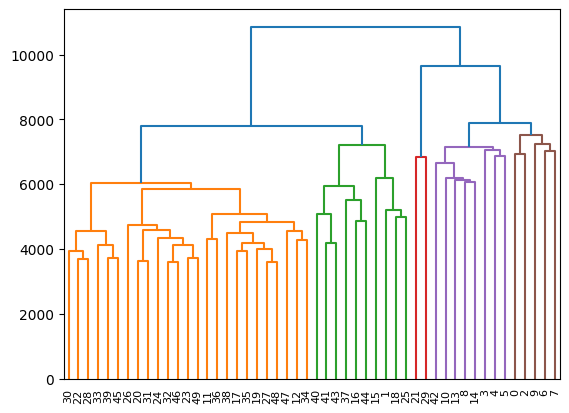

..cutHeight not given, setting it to 10776.245993136581  ===>  99% of the (truncated) height range in dendro.
..done.


In [389]:
D = np.zeros([50, 50])
for i in range(50):
    for j in range(i + 1, 50):
        D[i, j] = np.median(results[i][j][0])
        D[j, i] = D[i, j]

D = squareform(D)
Z = linkage(D, method="complete")
dendrogram(Z)
plt.show()

clusters = cutreeHybrid(Z, D, minClusterSize=1, deepSplit=3)

In [390]:
top_segments = segments.copy().iloc[:50, :]

ref_templates = []
for cl in np.unique(clusters["labels"]):
    ref_templates.append(top_segments[clusters["labels"] == cl].index[0])

ref_templ_idx = np.sort(np.array(ref_templates))
# ref_templ_idx = np.arange(50)
segments = segments.drop(index=ref_templ_idx).reset_index(drop=True)

X = X[:, ref_templ_idx]
X = np.delete(X, ref_templ_idx, axis=0)

In [391]:
labs = []
for i in range(len(segments)):
    I, _, _ = iou(catalog, segments.iloc[[i]].reset_index(drop=True))
    try:
        labs.append(
            catalog["label"][np.where(np.append(I[0], np.diff(I)) > 0)[0]].values[0]
        )
    except IndexError:
        labs.append(None)
labs = np.array(labs)

In [392]:
Xa = X.copy()
for i in range(Xa.shape[1]):
    x = np.delete(Xa[:, i], i)
    Xa[i, i] = np.min(x)

lens = []

for i in range(len(segments)):
    start = obspy.UTCDateTime(segments["start"][i])
    stop = obspy.UTCDateTime(segments["stop"][i])
    lens.append(min(stop - start, 1800))

lens = np.array(lens)
# lens = (lens == 1800).astype(float).reshape(-1, 1)
lens = lens.reshape(-1, 1)

Xa = np.hstack(
    [Xa, segments[["scores"]].values, lens, segments[["control_scores"]].values]
)
Xa = np.hstack([Xa, np.isnan(Xa[:, -1]).astype(float).reshape(-1, 1)])
Xa = np.nan_to_num(Xa, nan=0.5)
a = np.nanmin(Xa, axis=0)
b = np.nanmax(Xa, axis=0)
Xa = (Xa - a) / (b - a)

In [393]:
Z = linkage(Xa, method="ward")
D = squareform(pdist(Xa, metric="euclidean"))
clusters = cutreeHybrid(Z, D, minClusterSize=10, deepSplit=3)
clusters = clusters["labels"]
segments["cluster"] = clusters
segments["label"] = labs

..cutHeight not given, setting it to 14.926794521507775  ===>  99% of the (truncated) height range in dendro.
..done.


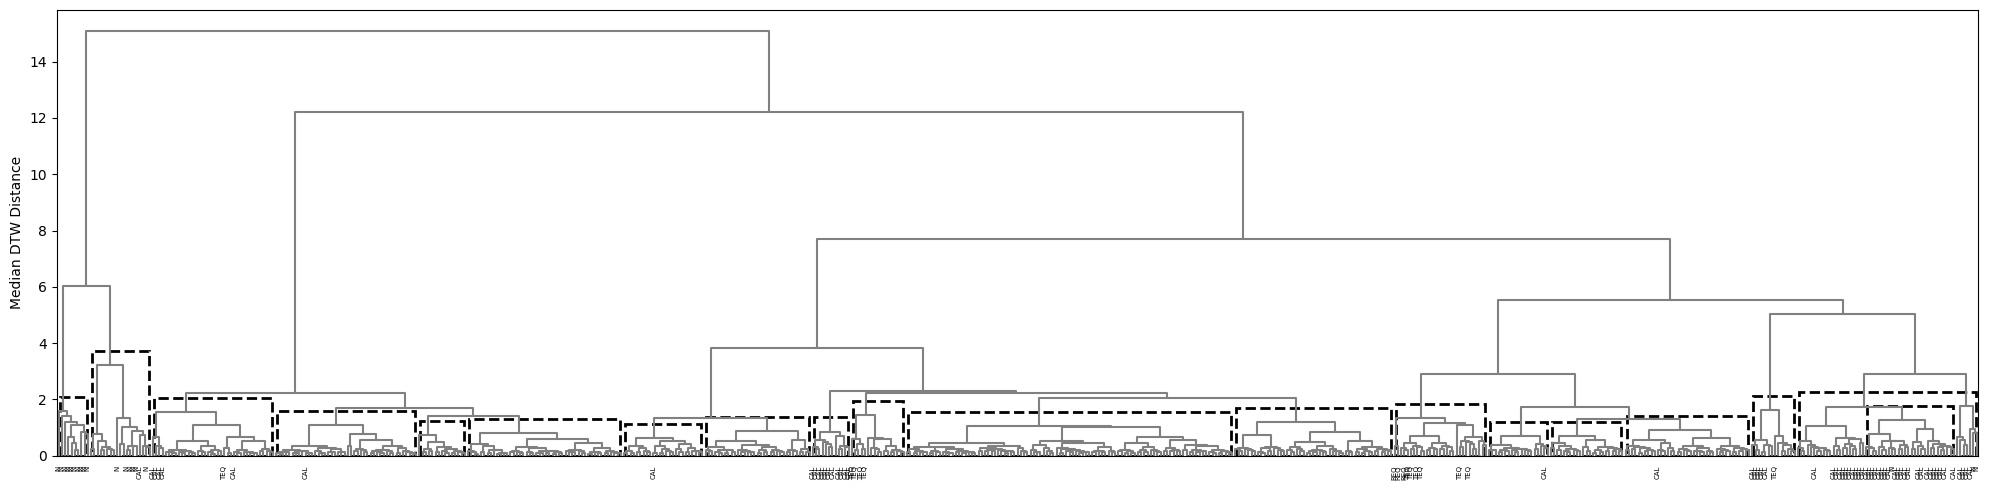

In [394]:
plt.figure(figsize=(20, 5))
# --- dendrogram ---
ddata = dendrogram(Z, labels=labs, link_color_func=lambda k: "grey")

leaf_order = ddata["leaves"]
clusters_ordered = clusters[leaf_order]

ax = plt.gca()

# x positions of leaves (scipy convention)
x_positions = np.arange(len(leaf_order)) * 10 + 5

# --- build tree structure to get correct heights ---
n = len(clusters)
node_members = {i: {i} for i in range(n)}
node_height = {i: 0 for i in range(n)}

for i, (c1, c2, dist, _) in enumerate(Z):
    c1, c2 = int(c1), int(c2)
    new_id = n + i

    members = node_members[c1] | node_members[c2]
    node_members[new_id] = members
    node_height[new_id] = dist

# --- compute height per cluster ---
cluster_heights = {}

for node_id, members in node_members.items():
    member_clusters = set(clusters[list(members)])

    if len(member_clusters) == 1:
        cid = next(iter(member_clusters))
        cluster_heights[cid] = max(cluster_heights.get(cid, 0), node_height[node_id])

# --- draw one box per cluster ---
gap = 8  # spacing so boxes don't touch

for cid in np.unique(clusters):
    idx = np.where(clusters_ordered == cid)[0]

    if len(idx) == 0:
        continue

    x0 = x_positions[idx.min()] - 5 + gap
    x1 = x_positions[idx.max()] + 5 - gap
    height = cluster_heights.get(cid, 0) + 0.5

    rect = plt.Rectangle(
        (x0, 0),
        x1 - x0,
        height,
        fill=False,
        edgecolor="black",
        linewidth=2,
        linestyle="--",
    )
    ax.add_patch(rect)

plt.ylabel("Median DTW Distance")
plt.tight_layout()
plt.savefig("../plots/karat_dendrogram.pdf", dpi=300)
plt.show()

In [395]:
info = {}
for cl in np.unique(clusters):
    cluster = segments[clusters == cl].copy().reset_index(drop=True)
    info[cl] = cluster_info(cluster)


df = pd.DataFrame(info).T
df.fillna(0, inplace=True)
df

label,EQ,MM,N,None
1,0.000000,0.000000,0.000000,1.000000
2,0.000000,0.000000,0.000000,1.000000
3,0.000000,0.000000,0.000000,1.000000
4,0.000000,0.022727,0.000000,0.977273
5,0.000000,0.025641,0.000000,0.974359
6,0.026316,0.131579,0.000000,0.842105
7,0.000000,0.000000,0.000000,1.000000
8,0.310345,0.000000,0.000000,0.689655
9,0.000000,0.535714,0.071429,0.392857
10,0.000000,0.785714,0.035714,0.178571


In [403]:
cl = 6
cluster = segments[clusters == cl].copy().reset_index(drop=True)
cluster

,start,stop,most_anomalous_start,scores,control_scores,cluster,label
0,2022-12-27T02:52:30.000000Z,2022-12-27T03:35:00.000000Z,2022-12-27T03:01:40.000000Z,0.715773,0.554152,6,CAL
1,2022-10-17T09:09:55.350000Z,2022-10-17T12:50:45.350000Z,2022-10-17T09:29:55.350000Z,0.703665,0.516989,6,CAL
2,2023-10-02T14:13:29.415000Z,2023-10-02T15:45:59.415000Z,2023-10-02T15:01:49.415000Z,0.701096,0.454392,6,CAL
3,2023-09-16T12:27:39.390000Z,2023-09-16T12:49:19.390000Z,2023-09-16T12:29:19.390000Z,0.698963,0.610813,6,CAL
4,2023-10-16T09:47:30.000000Z,2023-10-16T15:35:50.000000Z,2023-10-16T11:44:10.000000Z,0.675883,0.681411,6,TEQ
5,2022-12-02T10:32:29.350000Z,2022-12-02T19:21:39.350000Z,2022-12-02T18:47:29.350000Z,0.668329,0.624902,6,None
6,2022-12-02T19:21:42.440000Z,2022-12-03T01:07:32.440000Z,2022-12-02T19:50:02.440000Z,0.661134,0.615585,6,None
7,2023-10-06T09:47:30.000000Z,2023-10-07T09:51:40.000000Z,2023-10-06T21:39:10.000000Z,0.657926,0.585866,6,None
8,2023-10-12T03:21:40.000000Z,2023-10-13T08:51:40.000000Z,2023-10-12T21:19:10.000000Z,0.656355,0.548803,6,None
9,2022-10-15T19:42:25.350000Z,2022-10-16T09:27:25.350000Z,2022-10-16T00:14:05.350000Z,0.656098,0.551480,6,None


In [262]:
top_segments = segments.copy().iloc[:50, :]

ref_templates = []
for cl in np.unique(clusters["labels"]):
    ref_templates.append(top_segments[clusters["labels"] == cl].index[0])

ref_templ_idx = np.sort(np.array(ref_templates))
# ref_templ_idx = np.arange(50)
remaining_segments = segments.drop(index=ref_templ_idx).reset_index(drop=True)

In [263]:
labs = []
for i in range(len(remaining_segments)):
    I, _, _ = iou(catalog, remaining_segments.iloc[[i]].reset_index(drop=True))
    try:
        labs.append(
            catalog["label"][np.where(np.append(I[0], np.diff(I)) > 0)[0]].values[0]
        )
    except IndexError:
        labs.append(None)
labs = np.array(labs)

In [264]:
lens.shape

(605, 1)

In [265]:
Xa.shape

(605, 54)

In [266]:
Xa = X.copy()
Xa = Xa[:, ref_templ_idx]
Xa = np.delete(Xa, ref_templ_idx, axis=0)
lens = []

for i in range(len(remaining_segments)):
    start = obspy.UTCDateTime(remaining_segments["start"][i])
    stop = obspy.UTCDateTime(remaining_segments["stop"][i])
    lens.append(stop - start)

lens = np.array(lens)
lens = (lens >= 1800).astype(float).reshape(-1, 1)

Xa = np.hstack(
    (
        Xa,
        lens,
        remaining_segments["scores"].values.reshape(-1, 1),
        remaining_segments[["control_scores"]].values.reshape(-1, 1),
    )
)

a = np.nanmin(Xa, axis=0)
b = np.nanmax(Xa, axis=0)
Xa = np.nan_to_num(Xa, nan=0.5)
Xa = (Xa - a) / (b - a)

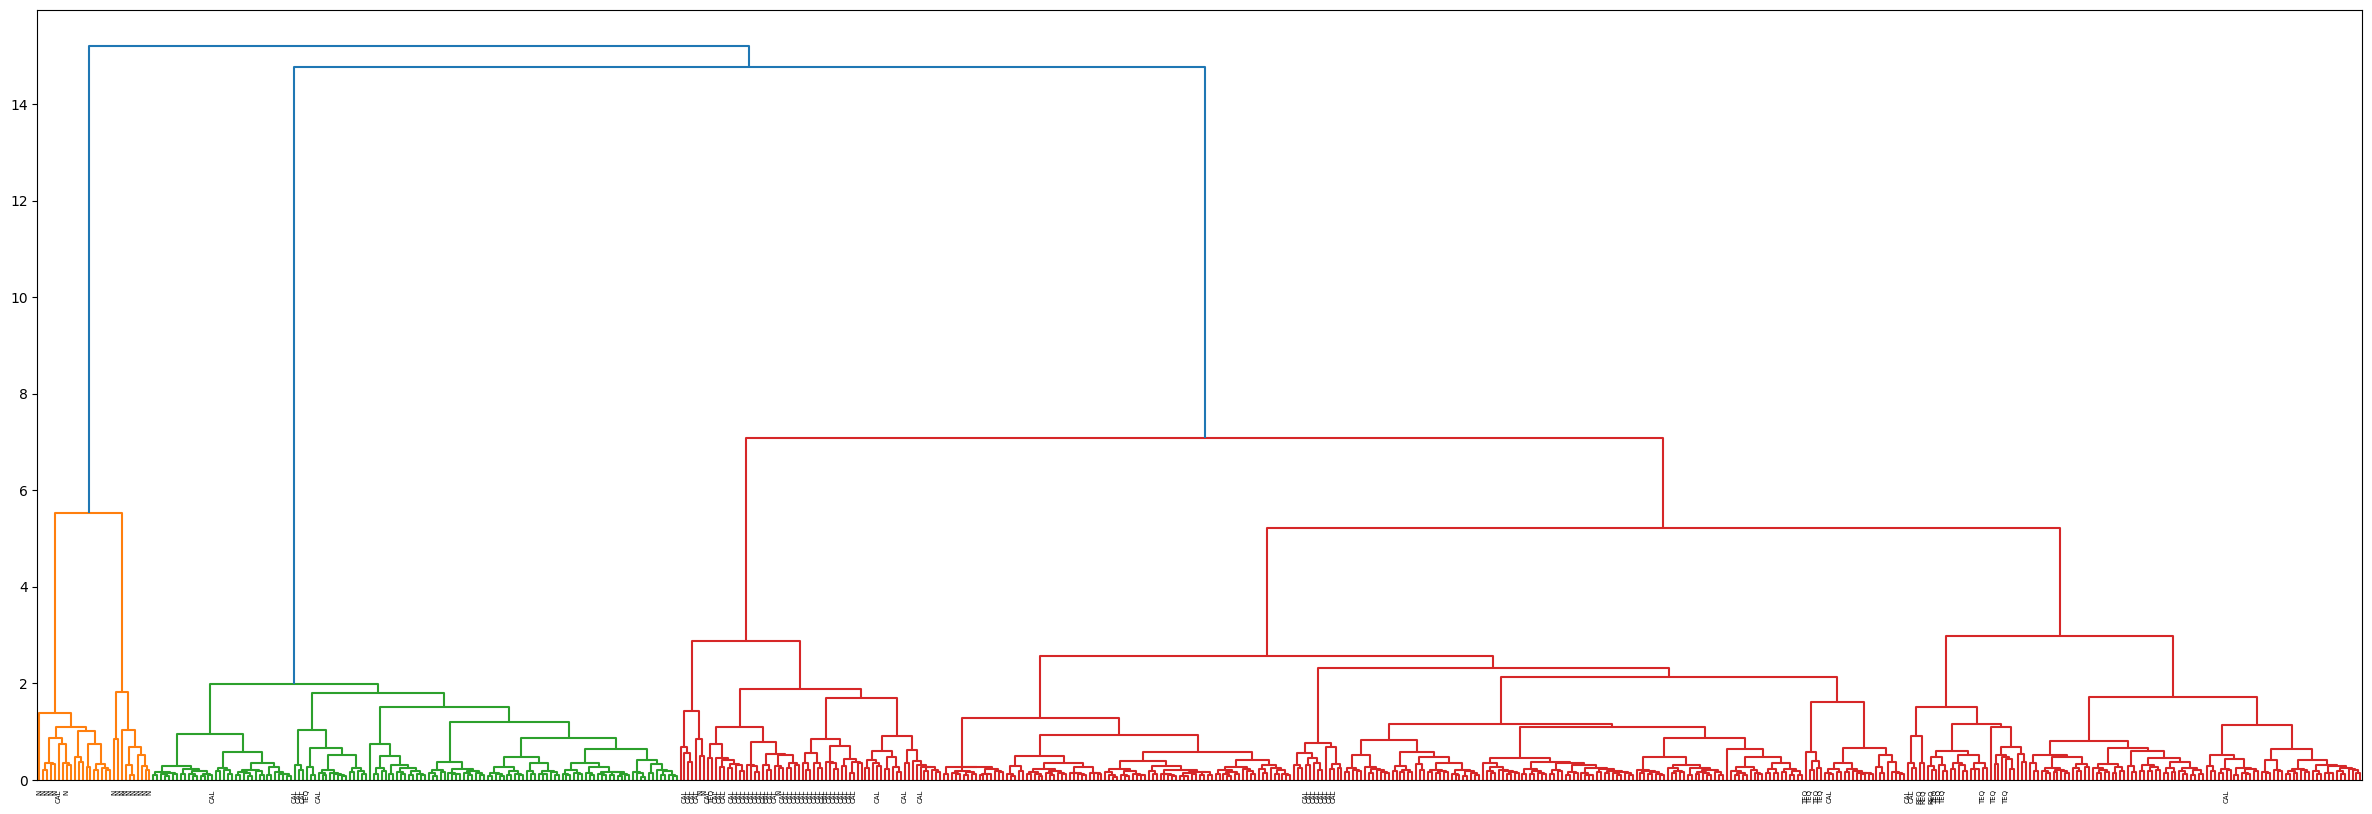

In [267]:
plt.figure(figsize=(30, 10))
Z = linkage(Xa, method="ward")
dendrogram(Z, labels=labs)
plt.show()

In [268]:
D = squareform(pdist(Xa, metric="euclidean"))
clusters = cutreeHybrid(Z, D, minClusterSize=10, deepSplit=3)["labels"]

..cutHeight not given, setting it to 15.045089715288164  ===>  99% of the (truncated) height range in dendro.
..done.


In [269]:
clusters.max()

18

In [270]:
remaining_segments = remaining_segments.reset_index(drop=True)

In [280]:
cl = 10
cluster = remaining_segments[clusters == cl].copy().reset_index(drop=True)
cluster

,start,stop,most_anomalous_start,scores,control_scores,cluster,label
0,2023-08-25T12:39:10.000000Z,2023-08-25T12:47:30.000000Z,2023-08-25T12:41:40.000000Z,0.720424,0.453202,8,CAL
1,2022-08-16T12:32:30.000000Z,2022-08-16T12:41:40.000000Z,2022-08-16T12:35:00.000000Z,0.716862,0.413724,8,N
2,2022-08-15T22:40:54.845000Z,2022-08-15T22:55:54.845000Z,2022-08-15T22:43:24.845000Z,0.702885,0.416311,8,N
3,2022-08-21T20:27:30.000000Z,2022-08-21T20:30:00.000000Z,2022-08-21T20:27:30.000000Z,0.636041,0.389330,8,CAL
4,2022-12-19T04:51:40.000000Z,2022-12-19T04:54:10.000000Z,2022-12-19T04:51:40.000000Z,0.635567,0.500232,8,CAL
5,2023-05-20T16:05:42.320000Z,2023-05-20T16:07:22.320000Z,2023-05-20T16:05:42.320000Z,0.632052,NaN,15,CAL
6,2023-04-14T05:11:32.320000Z,2023-04-14T05:14:02.320000Z,2023-04-14T05:11:32.320000Z,0.630583,0.366571,8,CAL
7,2022-08-24T11:23:39.410000Z,2022-08-24T11:27:49.410000Z,2022-08-24T11:24:29.410000Z,0.627558,0.469693,8,CAL
8,2022-12-13T12:28:20.000000Z,2022-12-13T12:30:50.000000Z,2022-12-13T12:28:20.000000Z,0.622735,0.460989,8,CAL
9,2023-07-26T01:00:50.000000Z,2023-07-26T01:03:20.000000Z,2023-07-26T01:00:50.000000Z,0.618290,0.375725,8,CAL


In [234]:
labs = []
for i in range(len(segments)):
    I, _, _ = iou(catalog, segments.iloc[[i]].reset_index(drop=True))
    try:
        labs.append(
            catalog["label"][np.where(np.append(I[0], np.diff(I)) > 0)[0]].values[0]
        )
    except IndexError:
        labs.append(None)
labs = np.array(labs)

In [ ]:
Xa = X.copy()
for i in range(Xa.shape[1]):
    x = np.delete(Xa[:, i], i)
    Xa[i, i] = np.min(x)

lens = []

for i in range(len(segments)):
    start = obspy.UTCDateTime(segments["start"][i])
    stop = obspy.UTCDateTime(segments["stop"][i])
    lens.append(min(stop - start, 1800))

lens = np.array(lens)
lens = (lens == 1800).astype(float).reshape(-1, 1)

Xa = np.hstack(
    [Xa, segments[["scores"]].values, lens, segments[["control_scores"]].values]
)
Xa = np.hstack([Xa, np.isnan(Xa[:, -1]).astype(float).reshape(-1, 1)])
Xa = np.nan_to_num(Xa, nan=0.5)
a = np.nanmin(Xa, axis=0)
b = np.nanmax(Xa, axis=0)
Xa = (Xa - a) / (b - a)

In [237]:
Z = linkage(Xa, method="ward")
D = squareform(pdist(Xa, metric="euclidean"))
clusters = cutreeHybrid(Z, D, minClusterSize=10, deepSplit=3)
clusters = clusters["labels"]
segments["cluster"] = clusters
segments["label"] = labs
segments.to_csv(f"../output/{network}/if/segments/{station}.csv")

..cutHeight not given, setting it to 30.10569914618996  ===>  99% of the (truncated) height range in dendro.
..done.


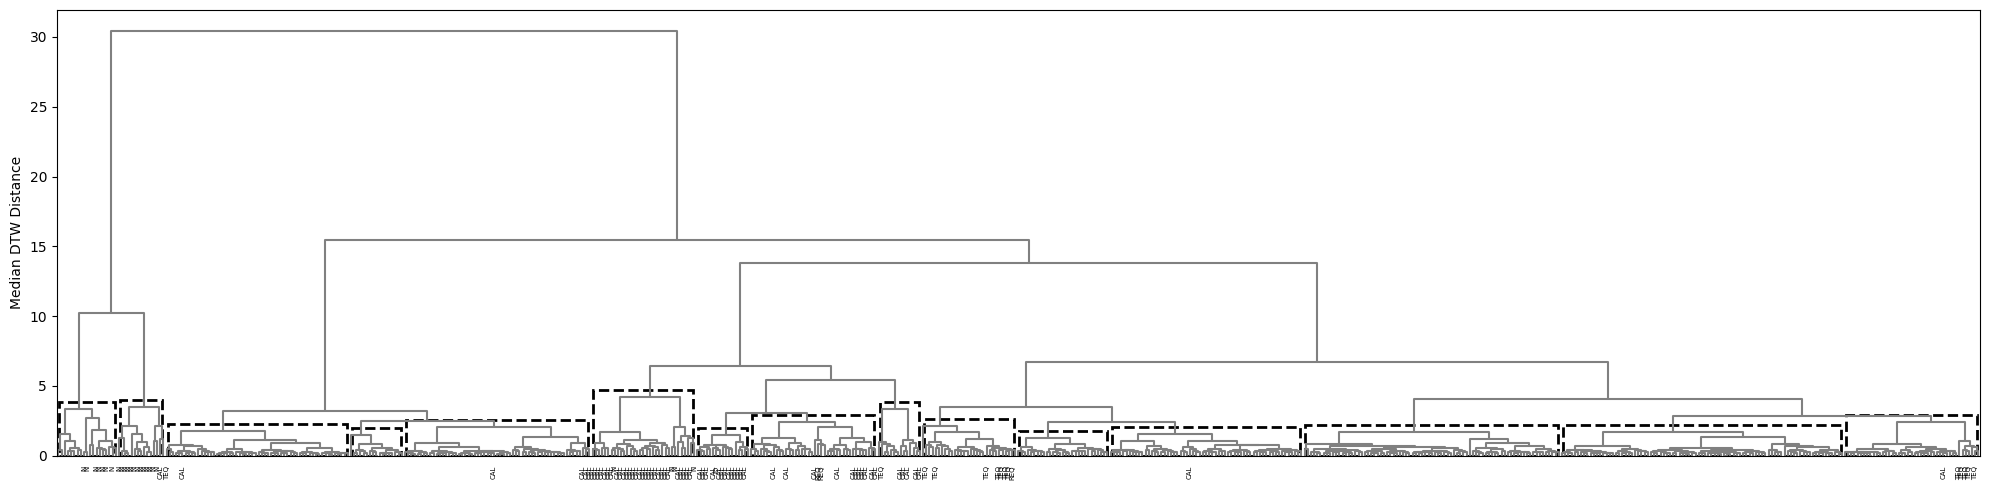

In [238]:
plt.figure(figsize=(20, 5))
# --- dendrogram ---
ddata = dendrogram(Z, labels=labs, link_color_func=lambda k: "grey")

leaf_order = ddata["leaves"]
clusters_ordered = clusters[leaf_order]

ax = plt.gca()

# x positions of leaves (scipy convention)
x_positions = np.arange(len(leaf_order)) * 10 + 5

# --- build tree structure to get correct heights ---
n = len(clusters)
node_members = {i: {i} for i in range(n)}
node_height = {i: 0 for i in range(n)}

for i, (c1, c2, dist, _) in enumerate(Z):
    c1, c2 = int(c1), int(c2)
    new_id = n + i

    members = node_members[c1] | node_members[c2]
    node_members[new_id] = members
    node_height[new_id] = dist

# --- compute height per cluster ---
cluster_heights = {}

for node_id, members in node_members.items():
    member_clusters = set(clusters[list(members)])

    if len(member_clusters) == 1:
        cid = next(iter(member_clusters))
        cluster_heights[cid] = max(cluster_heights.get(cid, 0), node_height[node_id])

# --- draw one box per cluster ---
gap = 8  # spacing so boxes don't touch

for cid in np.unique(clusters):
    idx = np.where(clusters_ordered == cid)[0]

    if len(idx) == 0:
        continue

    x0 = x_positions[idx.min()] - 5 + gap
    x1 = x_positions[idx.max()] + 5 - gap
    height = cluster_heights.get(cid, 0) + 0.5

    rect = plt.Rectangle(
        (x0, 0),
        x1 - x0,
        height,
        fill=False,
        edgecolor="black",
        linewidth=2,
        linestyle="--",
    )
    ax.add_patch(rect)

plt.ylabel("Median DTW Distance")
plt.tight_layout()
plt.savefig("../plots/karat_dendrogram.pdf", dpi=300)
plt.show()

In [16]:
clusters.max()

cl = 12
cluster = segments[clusters == cl].copy().reset_index(drop=True)
cluster

,start,stop,most_anomalous_start,scores,control_scores,cluster,label
0,2022-10-10T03:09:05.350000Z,2022-10-10T03:29:55.350000Z,2022-10-10T03:10:45.350000Z,0.726770,0.473050,12,CAL
1,2023-08-03T00:21:40.000000Z,2023-08-03T00:33:20.000000Z,2023-08-03T00:25:50.000000Z,0.723054,0.468209,12,ID
2,2023-07-03T09:22:22.320000Z,2023-07-03T09:39:52.320000Z,2023-07-03T09:34:52.320000Z,0.719906,0.463514,12,CAL
3,2022-12-27T02:52:30.000000Z,2022-12-27T03:35:00.000000Z,2022-12-27T03:01:40.000000Z,0.715773,0.554152,12,CAL
4,2023-04-11T11:35:42.320000Z,2023-04-11T11:42:22.320000Z,2023-04-11T11:37:22.320000Z,0.704491,0.443061,12,CAL
5,2022-10-17T09:09:55.350000Z,2022-10-17T12:50:45.350000Z,2022-10-17T09:29:55.350000Z,0.703665,0.516989,12,CAL
6,2023-10-02T14:13:29.415000Z,2023-10-02T15:45:59.415000Z,2023-10-02T15:01:49.415000Z,0.701096,0.454392,12,CAL
7,2023-08-21T09:51:40.000000Z,2023-08-21T09:59:10.000000Z,2023-08-21T09:53:20.000000Z,0.700739,0.520897,12,CAL
8,2023-09-16T12:27:39.390000Z,2023-09-16T12:49:19.390000Z,2023-09-16T12:29:19.390000Z,0.698963,0.610813,12,CAL
9,2023-04-11T12:31:32.320000Z,2023-04-11T12:37:22.320000Z,2023-04-11T12:34:02.320000Z,0.690807,0.436379,12,CAL


,start,stop,most_anomalous_start,scores,control_scores,cluster,label
0,2022-09-11T00:05:23.400000Z,2022-09-11T00:07:03.400000Z,2022-09-11T00:05:23.400000Z,0.671640,NaN,15,TEQ
1,2023-05-20T16:05:42.320000Z,2023-05-20T16:07:22.320000Z,2023-05-20T16:05:42.320000Z,0.632052,NaN,15,CAL
2,2023-05-01T06:29:52.320000Z,2023-05-01T06:31:32.320000Z,2023-05-01T06:29:52.320000Z,0.611004,NaN,15,CAL
3,2022-09-26T01:29:29.375000Z,2022-09-26T01:31:09.375000Z,2022-09-26T01:29:29.375000Z,0.610479,NaN,15,None
4,2022-09-22T09:09:37.390000Z,2022-09-22T09:11:17.390000Z,2022-09-22T09:09:37.390000Z,0.608948,NaN,15,CAL
5,2023-05-23T16:15:42.320000Z,2023-05-23T16:17:22.320000Z,2023-05-23T16:15:42.320000Z,0.605829,NaN,15,None
6,2022-09-26T03:35:29.375000Z,2022-09-26T03:37:09.375000Z,2022-09-26T03:35:29.375000Z,0.604144,NaN,15,None
7,2022-09-25T20:29:26.355000Z,2022-09-25T20:31:06.355000Z,2022-09-25T20:29:26.355000Z,0.603313,NaN,15,None
8,2023-02-19T13:25:47.055000Z,2023-02-19T13:27:27.055000Z,2023-02-19T13:25:47.055000Z,0.601963,NaN,15,None
9,2023-04-27T16:51:32.320000Z,2023-04-27T16:53:12.320000Z,2023-04-27T16:51:32.320000Z,0.601708,NaN,15,CAL


start                   2022-12-08T23:36:10.390000Z
stop                    2022-12-09T00:33:40.390000Z
most_anomalous_start    2022-12-08T23:36:10.390000Z
scores                                     0.610846
control_scores                              0.63957
cluster                                          11
label                                          None
Name: 19, dtype: object


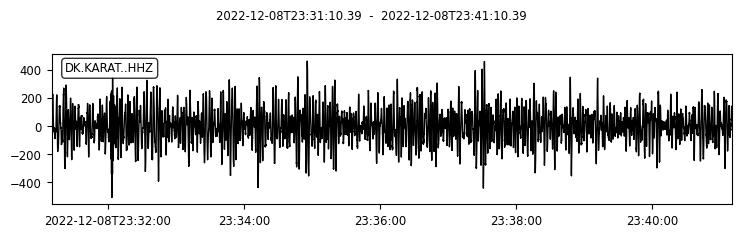

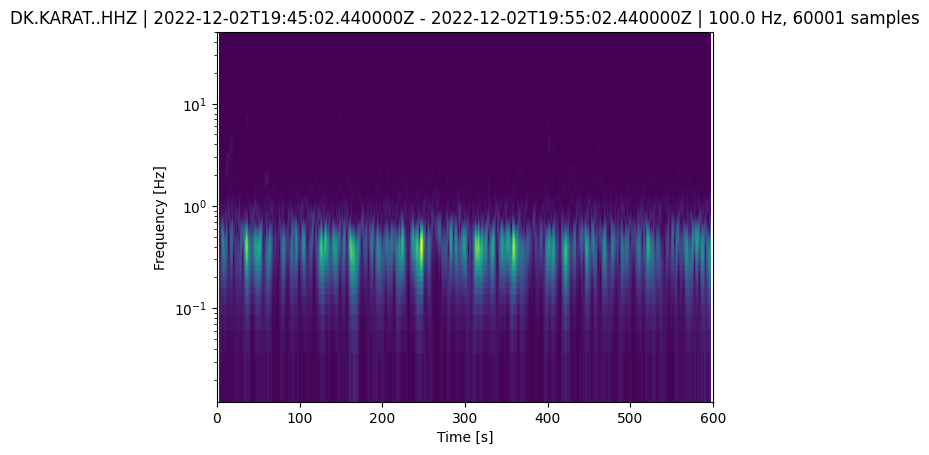

In [215]:
st[0].spectrogram(log=True, wlen=4, show=False)
plt.show()

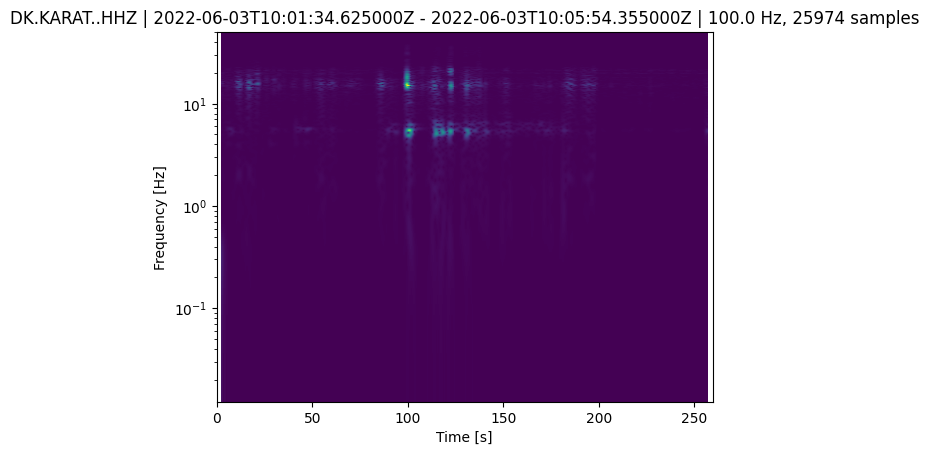

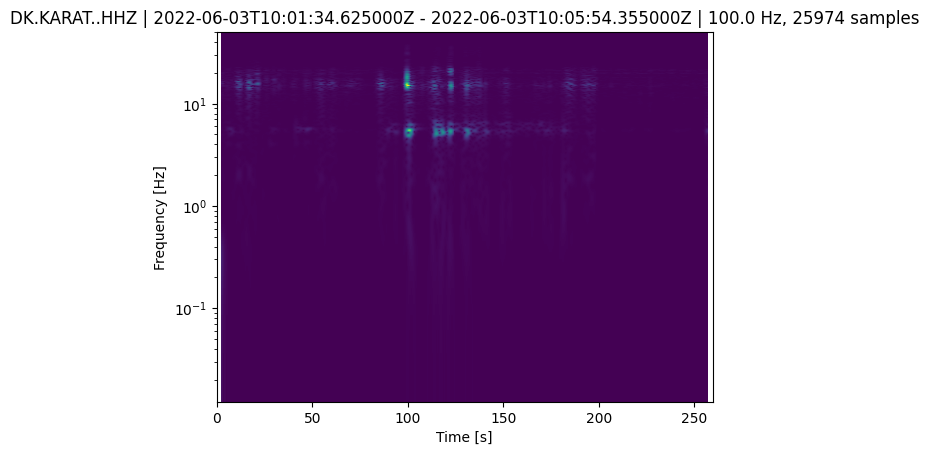

In [13]:
st[0].spectrogram(log=True, wlen=4, show=False)

### NUUG

In [249]:
station = "NUUG"
network = "DK"
nuug_paths = find_paths(network, station, "HHZ.D", start=2017, stop=2017)
segments = pd.read_csv(f"../output/{network}/if/segments/{station}.csv", index_col=0)

In [250]:
dtw_path = f"../output/{network}/dtw/distances"

with open(f"{dtw_path}/{station}.pkl", "rb") as f:
    results = pickle.load(f)

X = np.zeros((len(results), len(results[0])))
for i in range(len(results)):
    X[i] = np.array([np.median(results[i][k][0]) for k in range(len(results[i]))])

In [251]:
Xa = X.copy()
for i in range(Xa.shape[1]):
    x = np.delete(Xa[:, i], i)
    Xa[i, i] = np.min(x)

lens = []

for i in range(len(segments)):
    start = obspy.UTCDateTime(segments["start"][i])
    stop = obspy.UTCDateTime(segments["stop"][i])
    lens.append(min(stop - start, 1800))

lens = np.array(lens).reshape(-1, 1)

Xa = np.hstack(
    [Xa, segments[["scores"]].values, lens, segments[["control_scores"]].values]
)
Xa = np.nan_to_num(Xa, nan=0.5)
a = np.nanmin(Xa, axis=0)
b = np.nanmax(Xa, axis=0)
Xa = (Xa - a) / (b - a)

Z = linkage(Xa, method="ward")

In [252]:
D = squareform(pdist(Xa, metric="euclidean"))
clusters = cutreeHybrid(Z, D, minClusterSize=10, deepSplit=3)
clusters = clusters["labels"]

..cutHeight not given, setting it to 16.878350833069153  ===>  99% of the (truncated) height range in dendro.
..done.


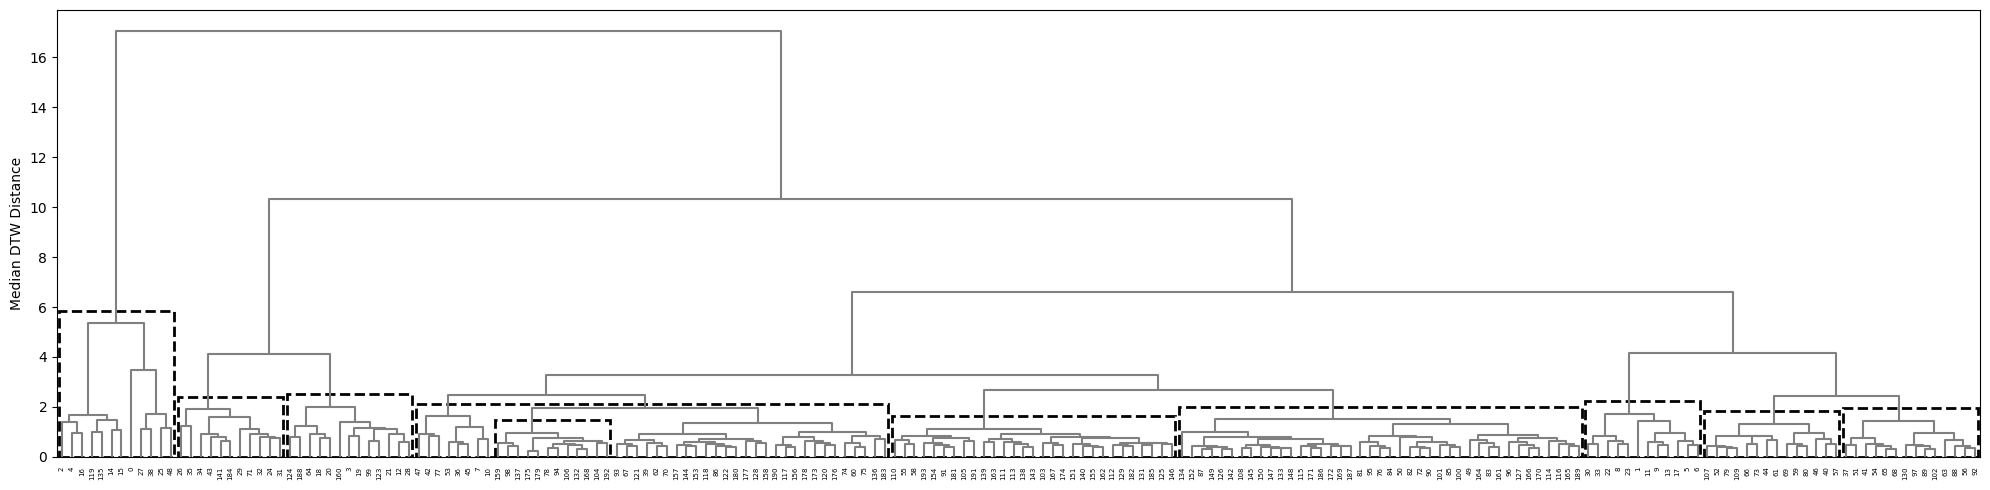

In [253]:
plt.figure(figsize=(20, 5))


# --- dendrogram ---
ddata = dendrogram(Z, link_color_func=lambda k: "grey")

leaf_order = ddata["leaves"]
clusters_ordered = clusters[leaf_order]

ax = plt.gca()

# x positions of leaves (scipy convention)
x_positions = np.arange(len(leaf_order)) * 10 + 5

# --- build tree structure to get correct heights ---
n = len(clusters)
node_members = {i: {i} for i in range(n)}
node_height = {i: 0 for i in range(n)}

for i, (c1, c2, dist, _) in enumerate(Z):
    c1, c2 = int(c1), int(c2)
    new_id = n + i

    members = node_members[c1] | node_members[c2]
    node_members[new_id] = members
    node_height[new_id] = dist

# --- compute height per cluster ---
cluster_heights = {}

for node_id, members in node_members.items():
    member_clusters = set(clusters[list(members)])

    if len(member_clusters) == 1:
        cid = next(iter(member_clusters))
        cluster_heights[cid] = max(cluster_heights.get(cid, 0), node_height[node_id])

# --- draw one box per cluster ---
gap = 2  # spacing so boxes don't touch

for cid in np.unique(clusters):
    idx = np.where(clusters_ordered == cid)[0]

    if len(idx) == 0:
        continue

    x0 = x_positions[idx.min()] - 5 + gap
    x1 = x_positions[idx.max()] + 5 - gap
    height = cluster_heights.get(cid, 0) + 0.5

    rect = plt.Rectangle(
        (x0, 0),
        x1 - x0,
        height,
        fill=False,
        edgecolor="black",
        linewidth=2,
        linestyle="--",
    )
    ax.add_patch(rect)

plt.ylabel("Median DTW Distance")
plt.tight_layout()
plt.savefig("../plots/nuug_dendrogram.pdf", dpi=300)
plt.show()

In [254]:
cl = 9

cluster = segments[clusters == cl].copy().reset_index(drop=True)
# cluster["label"] = labs[clusters == cl]
cluster

,start,stop,most_anomalous_start,scores,control_scores,cluster
0,2017-06-17T23:39:11.680001Z,2017-06-18T00:17:31.680001Z,2017-06-17T23:40:01.680001Z,0.737263,0.711354,9
1,2017-03-10T10:01:41.680001Z,2017-03-10T10:05:51.680001Z,2017-03-10T10:02:31.680001Z,0.729234,0.377912,9
2,2017-01-29T02:11:41.680001Z,2017-01-29T02:19:11.680001Z,2017-01-29T02:12:31.680001Z,0.716197,0.459733,9
3,2017-05-26T23:07:31.680001Z,2017-05-26T23:10:51.680001Z,2017-05-26T23:08:21.680001Z,0.691934,0.428958,9
4,2017-05-31T23:55:51.680001Z,2017-05-31T23:58:21.680001Z,2017-05-31T23:55:51.680001Z,0.690715,0.369397,9
5,2017-01-29T14:25:51.680001Z,2017-01-29T14:33:21.680001Z,2017-01-29T14:27:31.680001Z,0.686385,0.490783,9
6,2017-01-24T09:45:51.680001Z,2017-01-24T09:49:11.680001Z,2017-01-24T09:46:41.680001Z,0.669697,0.456603,9
7,2017-01-23T15:09:11.680001Z,2017-01-23T15:12:31.680001Z,2017-01-23T15:10:01.680001Z,0.660183,0.420810,9
8,2017-01-23T15:05:51.680001Z,2017-01-23T15:08:21.680001Z,2017-01-23T15:06:41.680001Z,0.649989,0.419752,9
9,2017-01-24T09:43:21.680001Z,2017-01-24T09:45:01.680001Z,2017-01-24T09:43:21.680001Z,0.641872,NaN,9


In [20]:
seg = cluster.iloc[11]
print(seg)
dt = str(seg["most_anomalous_start"])[:10]
t0 = obspy.UTCDateTime(seg["start"]) - timedelta(minutes=2)
t1 = obspy.UTCDateTime(seg["stop"]) + timedelta(minutes=2)

start                   2017-03-22T00:05:51.680001Z
stop                    2017-03-22T00:07:31.680001Z
most_anomalous_start    2017-03-22T00:05:51.680001Z
scores                                     0.608622
control_scores                                  NaN
cluster                                           9
Name: 11, dtype: object


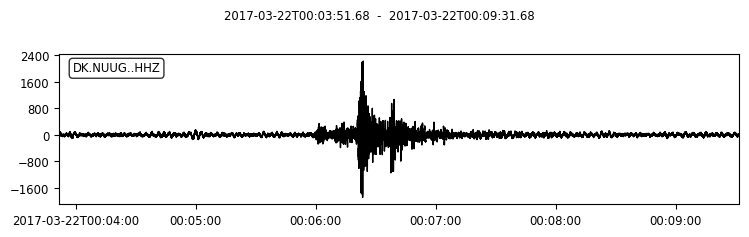

In [21]:
st = obspy.read(find_date_in_strings(nuug_paths, dt)[0])
preproc_stream(st)
st.trim(t0, t1)
st.plot()
plt.show()

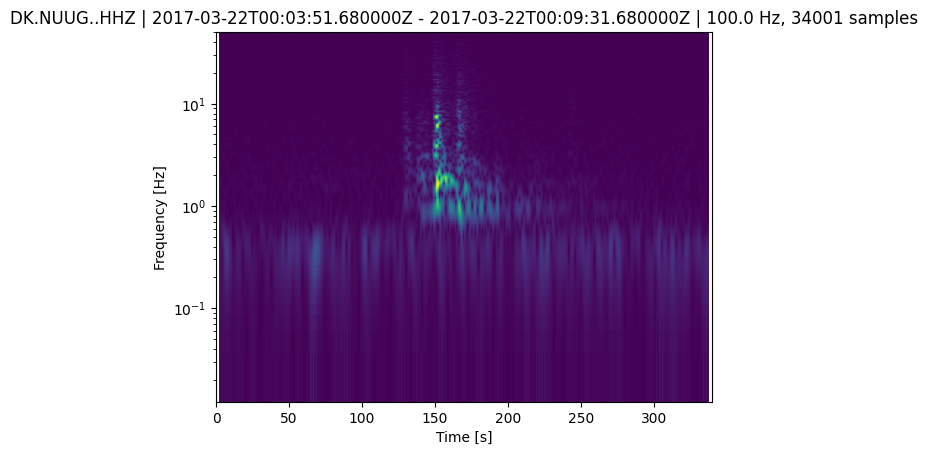

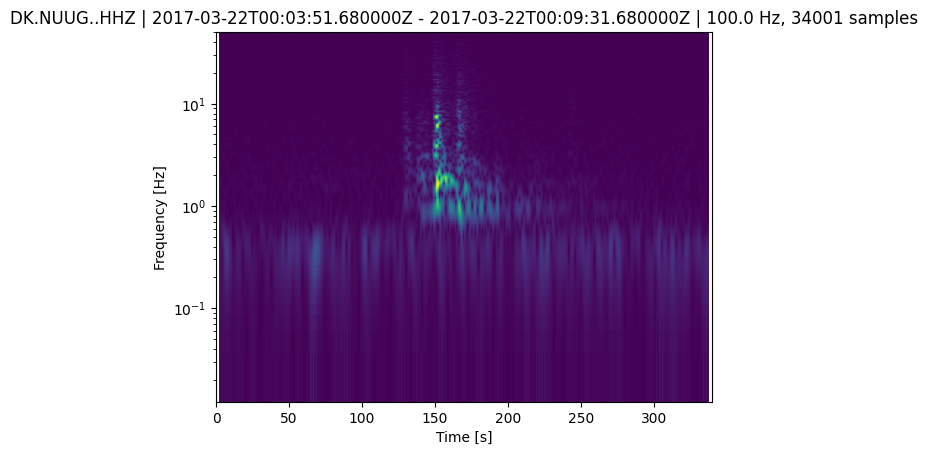

In [22]:
st[0].spectrogram(log=True, wlen=4, show=False)

In [23]:
segments["cluster"] = clusters

In [24]:
segments.to_csv(f"../output/{network}/if/segments/{station}.csv")

### ILL15

In [197]:
network = "XP"
station = "ILL15"
segments = pd.read_csv(f"../output/{network}/if/segments/{station}.csv", index_col=0)

In [198]:
dtw_path = f"../output/{network}/dtw/distances"

with open(f"{dtw_path}/{station}.pkl", "rb") as f:
    results = pickle.load(f)

X = np.zeros((len(results), len(results[0])))
for i in range(len(results)):
    X[i] = np.array([np.median(results[i][k][0]) for k in range(len(results[i]))])

lens = []

for i in range(len(segments)):
    start = obspy.UTCDateTime(segments["start"][i])
    stop = obspy.UTCDateTime(segments["stop"][i])
    lens.append(min(stop - start, 1800))

lens = np.array(lens).reshape(-1, 1)

Xa = X.copy()

Xa = np.hstack([Xa, segments[["scores"]].values, lens])

a = np.nanmin(Xa, axis=0)
b = np.nanmax(Xa, axis=0)
Xa = (Xa - a) / (b - a)

Z = linkage(Xa, method="ward")

In [199]:
D = squareform(pdist(Xa, metric="euclidean"))
clusters = cutreeHybrid(Z, D, minClusterSize=10, deepSplit=3)
clusters = clusters["labels"]

..cutHeight not given, setting it to 36.744844133316356  ===>  99% of the (truncated) height range in dendro.
..done.


In [200]:
catalog = pd.read_csv("../catalogs/XP/flow_catalog.csv")
catalog = preproc_flow_annotations(catalog)

catalog = catalog[catalog["station"] == station].reset_index(drop=True)
catalog = catalog[catalog["confidence"] == "high"].reset_index(drop=True)

labs = []
for i in range(len(segments)):
    I, _, _ = iou(catalog, segments.iloc[[i]].reset_index(drop=True))
    try:
        labs.append(
            catalog["confidence"][np.where(np.append(I[0], np.diff(I)) > 0)[0]].values[
                0
            ]
        )
    except IndexError:
        labs.append(None)
labs = np.array(labs)
labs[labs == "high"] = "F"

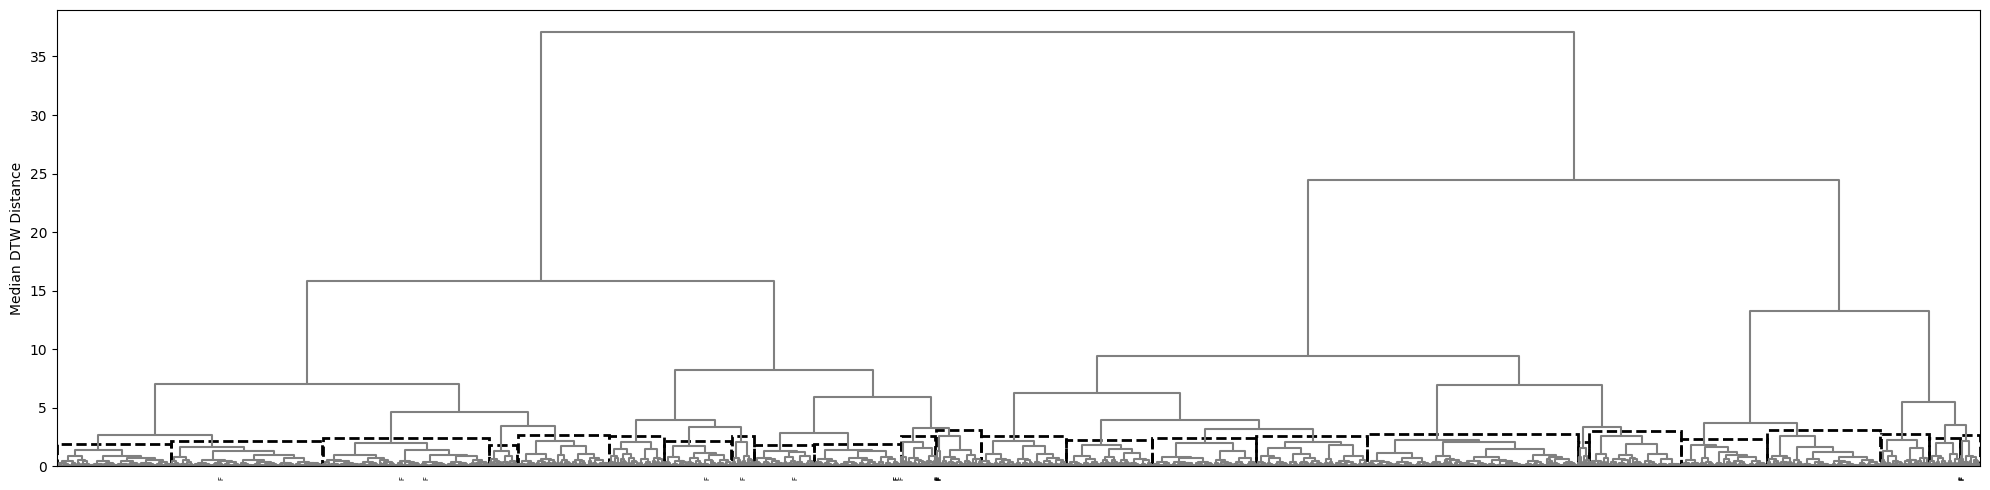

In [201]:
plt.figure(figsize=(20, 5))


# --- dendrogram ---
ddata = dendrogram(Z, link_color_func=lambda k: "grey", labels=labs)

leaf_order = ddata["leaves"]
clusters_ordered = clusters[leaf_order]

ax = plt.gca()

# x positions of leaves (scipy convention)
x_positions = np.arange(len(leaf_order)) * 10 + 5

# --- build tree structure to get correct heights ---
n = len(clusters)
node_members = {i: {i} for i in range(n)}
node_height = {i: 0 for i in range(n)}

for i, (c1, c2, dist, _) in enumerate(Z):
    c1, c2 = int(c1), int(c2)
    new_id = n + i

    members = node_members[c1] | node_members[c2]
    node_members[new_id] = members
    node_height[new_id] = dist

# --- compute height per cluster ---
cluster_heights = {}

for node_id, members in node_members.items():
    member_clusters = set(clusters[list(members)])

    if len(member_clusters) == 1:
        cid = next(iter(member_clusters))
        cluster_heights[cid] = max(cluster_heights.get(cid, 0), node_height[node_id])

# --- draw one box per cluster ---
gap = 2  # spacing so boxes don't touch

for cid in np.unique(clusters):
    idx = np.where(clusters_ordered == cid)[0]

    if len(idx) == 0:
        continue

    x0 = x_positions[idx.min()] - 5 + gap
    x1 = x_positions[idx.max()] + 5 - gap
    height = cluster_heights.get(cid, 0) + 0.5

    rect = plt.Rectangle(
        (x0, 0),
        x1 - x0,
        height,
        fill=False,
        edgecolor="black",
        linewidth=2,
        linestyle="--",
    )
    ax.add_patch(rect)

plt.ylabel("Median DTW Distance")
plt.tight_layout()
# plt.savefig("../plots/nuug_dendrogram.pdf", dpi=300)
plt.show()

In [236]:
cl = 19
df = segments[clusters == cl].copy().reset_index(drop=True)
df["labels"] = labs[clusters == cl]
print(np.mean(df["labels"] == "F"))
df[df["labels"] == "F"]

0.01282051282051282


,start,stop,most_anomalous_start,scores,labels
14,2021-07-06T18:47:29.990000Z,2021-07-06T19:03:19.990000Z,2021-07-06T18:49:59.990000Z,0.683823,F


In [237]:
df.shape

(78, 5)

In [203]:
clusters.max()

24

In [196]:
df

,start,stop,most_anomalous_start,scores,labels
0,2022-06-01T11:15:12.650000Z,2022-06-01T11:25:12.650000Z,2022-06-01T11:21:02.650000Z,0.744285,None
1,2022-05-14T23:56:02.650000Z,2022-05-15T00:01:52.650000Z,2022-05-14T23:57:42.650000Z,0.741609,None
2,2020-09-01T00:01:34.070000Z,2020-09-01T00:06:34.070000Z,2020-09-01T00:03:14.070000Z,0.720797,None
3,2018-08-08T17:41:41.850003Z,2018-08-08T17:57:31.850003Z,2018-08-08T17:45:01.850003Z,0.718818,F
4,2022-05-14T15:27:42.650000Z,2022-05-14T15:32:42.650000Z,2022-05-14T15:28:32.650000Z,0.710851,None
...,...,...,...,...,...
105,2021-09-19T07:44:08.020000Z,2021-09-19T07:48:18.020000Z,2021-09-19T07:44:08.020000Z,0.593165,None
106,2022-06-08T12:37:42.650000Z,2022-06-08T12:53:32.650000Z,2022-06-08T12:45:12.650000Z,0.592896,None
107,2021-06-08T20:56:38.020000Z,2021-06-08T20:58:18.020000Z,2021-06-08T20:56:38.020000Z,0.589628,None
108,2022-06-22T21:32:42.650000Z,2022-06-22T21:47:42.650000Z,2022-06-22T21:36:02.650000Z,0.583549,None
